In [2]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import pandas as pd
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])  
import os
from w_theta_helper import compute_w_theta

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [6]:
w_ref_south_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')
w_ref_north_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_north_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')
#w_ref_south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_30_0.01_to_15.npy')



In [7]:
path = 'imaging_systematics_maps/data/'
systematics_list = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD','PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1']
part= 'full'
mask =hp.read_map(f'{path}/{part}_mask_nside_64_for_systmatics_20M.fits')
randoms_counts = hp.read_map(f'{path}/{part}_counts_randoms_nside_64.fits')
systematics_maps = {}
for sys_name in systematics_list:
    sys_map = hp.read_map(f'{path}/{part}_{sys_name}_nside_64.fits')
    systematics_maps[sys_name] = sys_map
    data  =sys_map[mask>0]


###quantile the maps based on the full sky coverage
n_bins = 3
bins_sys= {}
quantiles_sys = {}
for sys_name in systematics_list:
    sys_map = systematics_maps[sys_name]
    data  =sys_map[mask>0]
    quantiles = np.nanpercentile(data, np.linspace(0, 100, n_bins + 1))
    quantiles_sys[sys_name] = quantiles
    bins_sys[sys_name] = np.linspace(np.nanpercentile(data, 0.1), np.nanpercentile(data, 99.9),60)
    print(f'{sys_name} quantiles: {quantiles}')


H_Alpha quantiles: [ 0.1000061   0.6580517   1.23740553 27.96468801]
Saggitarius_Density quantiles: [-7.10268540e-05  1.34998679e-11  1.18749518e-01  3.26996910e+01]
Stellar_Density_AllWISE quantiles: [21.64236069 24.01313273 28.27901332 57.1450119 ]
CSFD quantiles: [0.005288   0.0279125  0.05203247 0.94555005]
PSFDEPTH_Z quantiles: [21.36937237 23.22911859 23.36825897 24.18952761]
PSFDEPTH_G quantiles: [23.16131676 24.47520699 24.77050003 25.68547529]
PSFDEPTH_R quantiles: [21.72649568 23.9237542  24.19688228 25.38027049]
PSFSIZE_G quantiles: [0.94856612 1.48503232 1.71477542 2.87674737]
PSFSIZE_R quantiles: [0.86435641 1.34886903 1.5529384  2.74848036]
PSFSIZE_Z quantiles: [0.82218245 1.20754454 1.34614055 2.14208903]
PSFDEPTH_W1 quantiles: [20.74259699 21.34817317 21.44054384 22.13258302]


In [8]:
area_north = 5155.73 # deg^2
area_south = 12179.53  # deg^2
area = {}
area['south'] = area_south
area['north'] = area_north


In [9]:
nbins = 3
randoms = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_5M.fits')[1].read())
randoms_part={}
randoms_part['north'] = randoms[randoms['PHOTSYS'] == 'N']
randoms_part['south'] = randoms[randoms['PHOTSYS'] == 'S']
randoms_part['south'] = randoms_part['south'][randoms_part['south']['DEC'] > -30]

In [10]:
density_south_randoms = len(randoms_part['south'])/area['south']
density_north_randoms = len(randoms_part['north'])/area['north']
density_randoms = {}
density_randoms['south'] = density_south_randoms
density_randoms['north'] = density_north_randoms
print(f"Density in South randoms: {density_south_randoms:.2f} objects/deg^2")
print(f"Density in North randoms: {density_north_randoms:.2f} objects/deg^2")

Density in South randoms: 4588.66 objects/deg^2
Density in North randoms: 4594.76 objects/deg^2


In [11]:
colors= ['r','k']
for sys_name in systematics_list:
    
    for survey in ['north','south']:
        sys_map = hp.read_map(f'{path}/{survey}_{sys_name}_nside_64.fits')
        mask =hp.read_map(f'{path}/{survey}_mask_nside_64_for_systmatics_20M.fits')
        #randoms_counts = hp.read_map(f'{path}/{survey}_counts_randoms_nside_64.fits')
        data  =sys_map[mask>0]
        #quantiles = np.nanpercentile(data, np.linspace(0, 100, n_bins + 1))
        quantile_edges = quantiles_sys[sys_name]
        quantile_counts, edges = np.histogram(data, bins=quantile_edges)

        random_pix  = hp.ang2pix(64, np.radians(90.0 - randoms_part[survey]['DEC']), np.radians(randoms_part[survey]['RA']), nest=False)
        bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
        bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
        number_randoms_in_bins = np.bincount(bin_indices_randoms, minlength=nbins)
        print(f"\n{survey} - {sys_name}")
        area_quantile = number_randoms_in_bins / density_randoms[survey]
        print(area_quantile)
        for i, c in enumerate(quantile_counts):
            print(f"Q{i+1}: [{quantile_edges[i]:.6g}, {quantile_edges[i+1]:.6g}) -> {c} objects with density {c/area_quantile[i]:.2f} objects/deg^2")
        break
        #plt.hist(data, bins=bins_sys[sys_name], alpha=0.5, label=f'{survey} - {sys_name}',density=True,color=colors[0] if survey=='north' else colors[1],edgecolor=colors[0] if survey=='north' else colors[1])
        




north - H_Alpha
[2448.77900865 1625.76541191 1081.18557943]
Q1: [0.100006, 0.658052) -> 2974 objects with density 1.21 objects/deg^2
Q2: [0.658052, 1.23741) -> 1970 objects with density 1.21 objects/deg^2
Q3: [1.23741, 27.9647) -> 1426 objects with density 1.32 objects/deg^2

north - Saggitarius_Density
[2306.54586376 2792.73220721   56.45192903]
Q1: [-7.10269e-05, 1.34999e-11) -> 2860 objects with density 1.24 objects/deg^2
Q2: [1.34999e-11, 0.11875) -> 3419 objects with density 1.22 objects/deg^2
Q3: [0.11875, 32.6997) -> 91 objects with density 1.61 objects/deg^2

north - Stellar_Density_AllWISE
[1622.04029802 1826.58552716 1707.10417482]
Q1: [21.6424, 24.0131) -> 1981 objects with density 1.22 objects/deg^2
Q2: [24.0131, 28.279) -> 2207 objects with density 1.21 objects/deg^2
Q3: [28.279, 57.145) -> 2182 objects with density 1.28 objects/deg^2

north - CSFD
[2917.88262748 1142.21533305 1095.63203947]
Q1: [0.005288, 0.0279125) -> 3545 objects with density 1.21 objects/deg^2
Q2: [0.


north - H_Alpha
Q1: [0.100006, 0.658052) -> 2974 objects with density 1.21 objects/deg^2
Q2: [0.658052, 1.23741) -> 1970 objects with density 1.21 objects/deg^2
Q3: [1.23741, 27.9647) -> 1426 objects with density 1.32 objects/deg^2

south - H_Alpha
Q1: [0.100006, 0.658052) -> 4268 objects with density 1.23 objects/deg^2
Q2: [0.658052, 1.23741) -> 5198 objects with density 1.22 objects/deg^2
Q3: [1.23741, 27.9647) -> 5761 objects with density 1.29 objects/deg^2


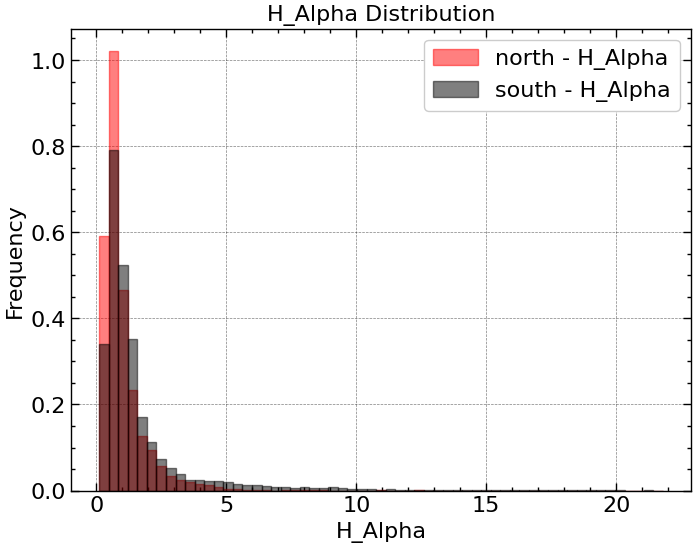


north - Saggitarius_Density
Q1: [-7.10269e-05, 1.34999e-11) -> 2860 objects with density 1.24 objects/deg^2
Q2: [1.34999e-11, 0.11875) -> 3419 objects with density 1.22 objects/deg^2
Q3: [0.11875, 32.6997) -> 91 objects with density 1.61 objects/deg^2

south - Saggitarius_Density
Q1: [-7.10269e-05, 1.34999e-11) -> 4370 objects with density 1.28 objects/deg^2
Q2: [1.34999e-11, 0.11875) -> 3787 objects with density 1.26 objects/deg^2
Q3: [0.11875, 32.6997) -> 7070 objects with density 1.23 objects/deg^2


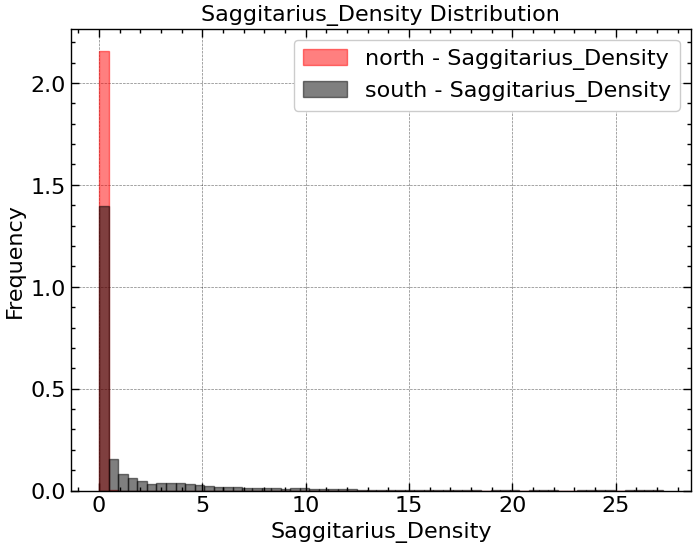


north - Stellar_Density_AllWISE
Q1: [21.6424, 24.0131) -> 1981 objects with density 1.22 objects/deg^2
Q2: [24.0131, 28.279) -> 2207 objects with density 1.21 objects/deg^2
Q3: [28.279, 57.145) -> 2182 objects with density 1.28 objects/deg^2

south - Stellar_Density_AllWISE
Q1: [21.6424, 24.0131) -> 5245 objects with density 1.22 objects/deg^2
Q2: [24.0131, 28.279) -> 4975 objects with density 1.23 objects/deg^2
Q3: [28.279, 57.145) -> 5007 objects with density 1.31 objects/deg^2


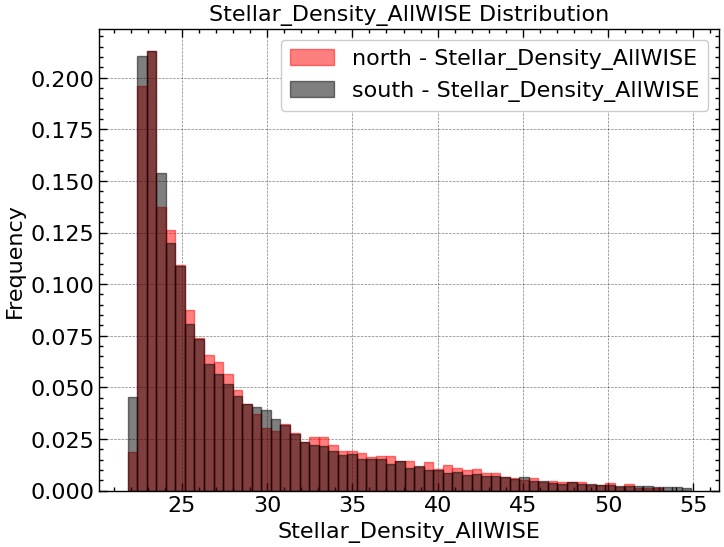


north - CSFD
Q1: [0.005288, 0.0279125) -> 3545 objects with density 1.21 objects/deg^2
Q2: [0.0279125, 0.0520325) -> 1389 objects with density 1.22 objects/deg^2
Q3: [0.0520325, 0.94555) -> 1436 objects with density 1.31 objects/deg^2

south - CSFD
Q1: [0.005288, 0.0279125) -> 3727 objects with density 1.24 objects/deg^2
Q2: [0.0279125, 0.0520325) -> 5784 objects with density 1.23 objects/deg^2
Q3: [0.0520325, 0.94555) -> 5716 objects with density 1.28 objects/deg^2


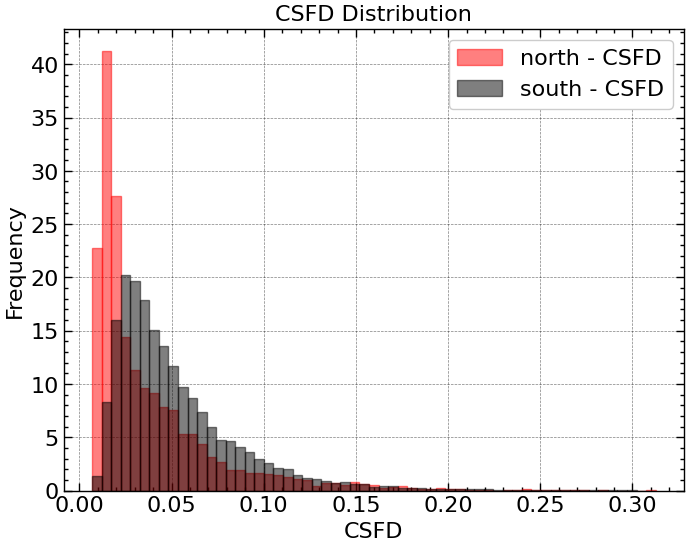


north - PSFDEPTH_Z
Q1: [21.3694, 23.2291) -> 1417 objects with density 1.26 objects/deg^2
Q2: [23.2291, 23.3683) -> 2742 objects with density 1.21 objects/deg^2
Q3: [23.3683, 24.1895) -> 2128 objects with density 1.20 objects/deg^2

south - PSFDEPTH_Z
Q1: [21.3694, 23.2291) -> 5729 objects with density 1.29 objects/deg^2
Q2: [23.2291, 23.3683) -> 4327 objects with density 1.20 objects/deg^2
Q3: [23.3683, 24.1895) -> 4935 objects with density 1.19 objects/deg^2


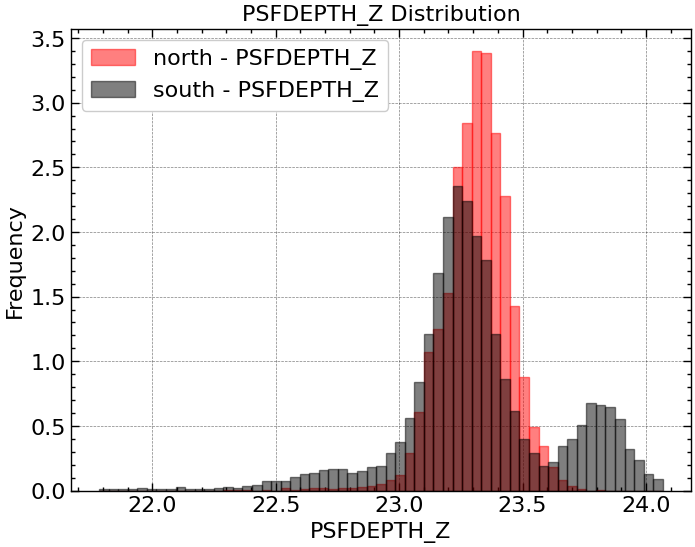


north - PSFDEPTH_G
Q1: [23.1613, 24.4752) -> 5994 objects with density 1.23 objects/deg^2
Q2: [24.4752, 24.7705) -> 329 objects with density 1.21 objects/deg^2
Q3: [24.7705, 25.6855) -> 1 objects with density 0.21 objects/deg^2

south - PSFDEPTH_G
Q1: [23.1613, 24.4752) -> 1011 objects with density 1.54 objects/deg^2
Q2: [24.4752, 24.7705) -> 6624 objects with density 1.21 objects/deg^2
Q3: [24.7705, 25.6855) -> 6927 objects with density 1.14 objects/deg^2


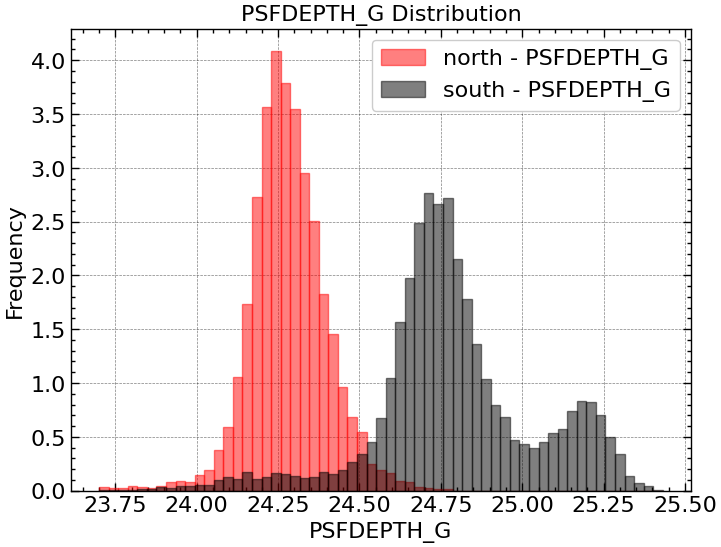


north - PSFDEPTH_R
Q1: [21.7265, 23.9238) -> 6171 objects with density 1.23 objects/deg^2
Q2: [23.9238, 24.1969) -> 154 objects with density 1.24 objects/deg^2
Q3: [24.1969, 25.3803) -> 1 objects with density 0.22 objects/deg^2

south - PSFDEPTH_R
Q1: [21.7265, 23.9238) -> 835 objects with density 1.54 objects/deg^2
Q2: [23.9238, 24.1969) -> 6812 objects with density 1.22 objects/deg^2
Q3: [24.1969, 25.3803) -> 6917 objects with density 1.14 objects/deg^2


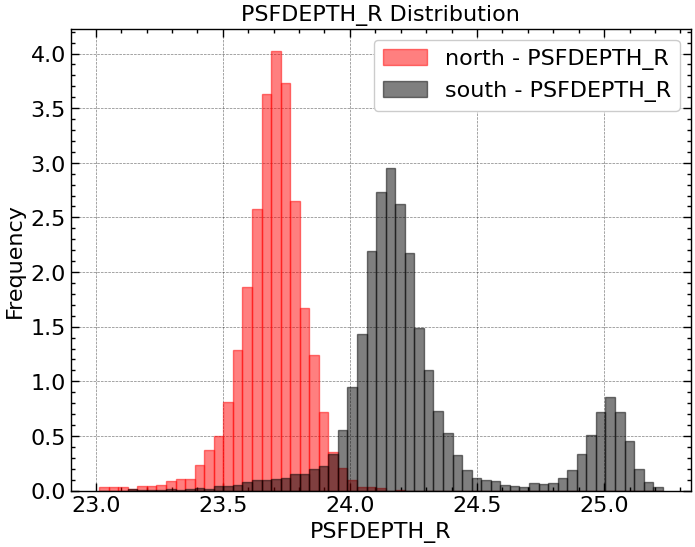


north - PSFSIZE_G
Q1: [0.948566, 1.48503) -> 39 objects with density 1.68 objects/deg^2
Q2: [1.48503, 1.71478) -> 796 objects with density 1.26 objects/deg^2
Q3: [1.71478, 2.87675) -> 5489 objects with density 1.22 objects/deg^2

south - PSFSIZE_G
Q1: [0.948566, 1.48503) -> 6879 objects with density 1.22 objects/deg^2
Q2: [1.48503, 1.71478) -> 6173 objects with density 1.22 objects/deg^2
Q3: [1.71478, 2.87675) -> 1510 objects with density 1.02 objects/deg^2


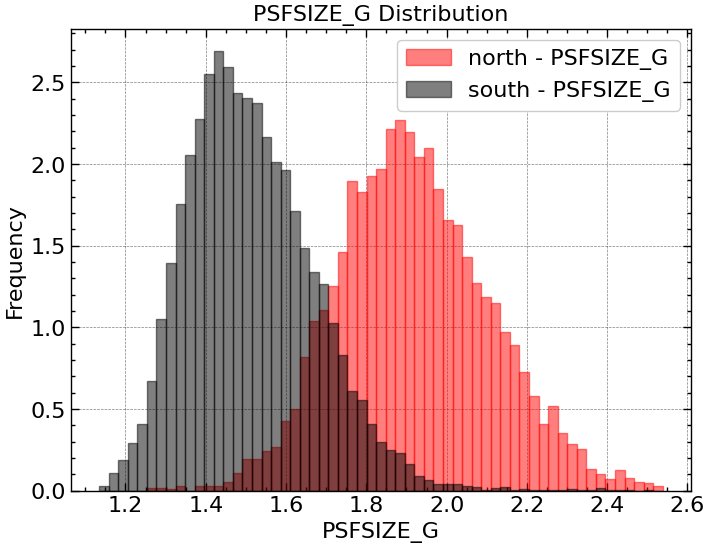


north - PSFSIZE_R
Q1: [0.864356, 1.34887) -> 121 objects with density 1.25 objects/deg^2
Q2: [1.34887, 1.55294) -> 1425 objects with density 1.24 objects/deg^2
Q3: [1.55294, 2.74848) -> 4780 objects with density 1.22 objects/deg^2

south - PSFSIZE_R
Q1: [0.864356, 1.34887) -> 6797 objects with density 1.22 objects/deg^2
Q2: [1.34887, 1.55294) -> 5554 objects with density 1.22 objects/deg^2
Q3: [1.55294, 2.74848) -> 2213 objects with density 1.07 objects/deg^2


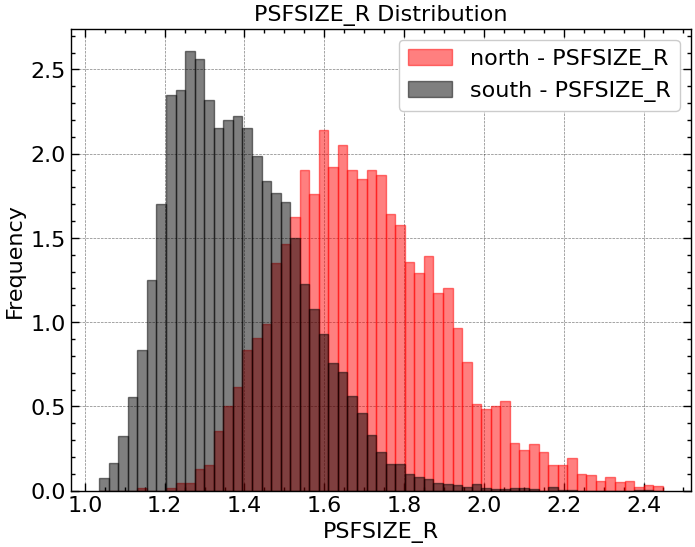


north - PSFSIZE_Z
Q1: [0.822182, 1.20754) -> 2136 objects with density 1.22 objects/deg^2
Q2: [1.20754, 1.34614) -> 2749 objects with density 1.21 objects/deg^2
Q3: [1.34614, 2.14209) -> 1403 objects with density 1.23 objects/deg^2

south - PSFSIZE_Z
Q1: [0.822182, 1.20754) -> 4941 objects with density 1.24 objects/deg^2
Q2: [1.20754, 1.34614) -> 4323 objects with density 1.23 objects/deg^2
Q3: [1.34614, 2.14209) -> 5727 objects with density 1.23 objects/deg^2


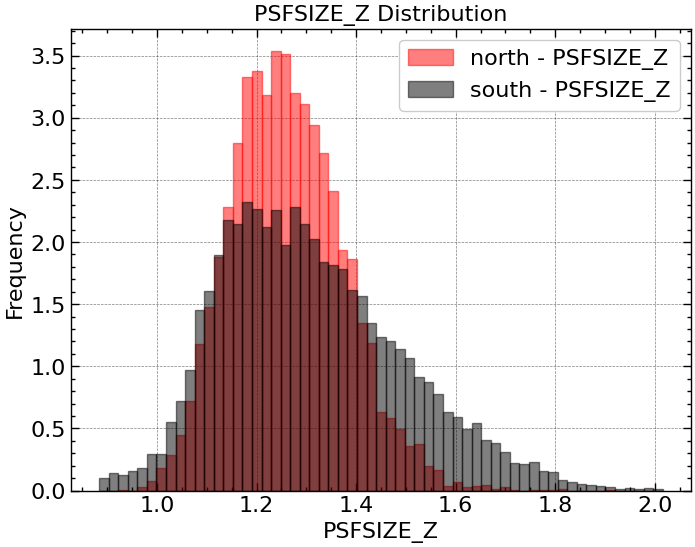


north - PSFDEPTH_W1
Q1: [20.7426, 21.3482) -> 378 objects with density 1.33 objects/deg^2
Q2: [21.3482, 21.4405) -> 901 objects with density 1.25 objects/deg^2
Q3: [21.4405, 22.1326) -> 5091 objects with density 1.23 objects/deg^2

south - PSFDEPTH_W1
Q1: [20.7426, 21.3482) -> 6782 objects with density 1.25 objects/deg^2
Q2: [21.3482, 21.4405) -> 6266 objects with density 1.25 objects/deg^2
Q3: [21.4405, 22.1326) -> 2173 objects with density 1.27 objects/deg^2


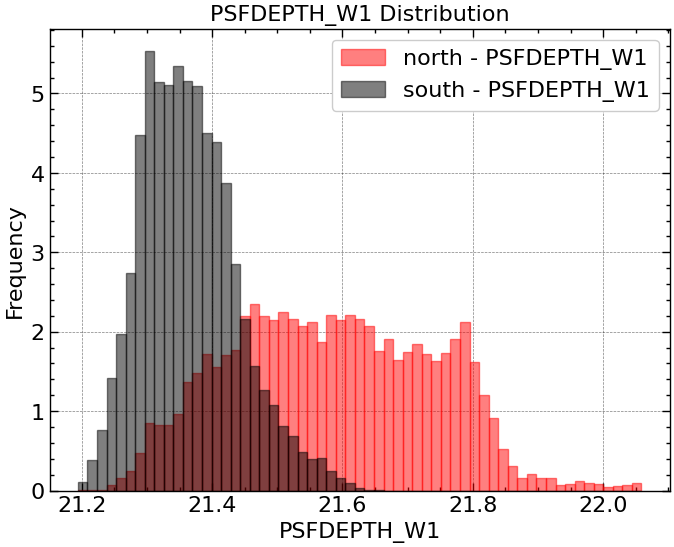

In [12]:
colors= ['r','k']
for sys_name in systematics_list:
    
    for survey in ['north','south']:
        sys_map = hp.read_map(f'{path}/{survey}_{sys_name}_nside_64.fits')
        mask =hp.read_map(f'{path}/{survey}_mask_nside_64_for_systmatics_20M.fits')
        #randoms_counts = hp.read_map(f'{path}/{survey}_counts_randoms_nside_64.fits')
        data  =sys_map[mask>0]
        #quantiles = np.nanpercentile(data, np.linspace(0, 100, n_bins + 1))
        quantile_edges = quantiles_sys[sys_name]
        quantile_counts, edges = np.histogram(data, bins=quantile_edges)

        random_pix  = hp.ang2pix(64, np.radians(90.0 - randoms_part[survey]['DEC']), np.radians(randoms_part[survey]['RA']), nest=False)
        bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
        bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
        number_randoms_in_bins = np.bincount(bin_indices_randoms, minlength=nbins)
        print(f"\n{survey} - {sys_name}")
        area_quantile = number_randoms_in_bins / density_randoms[survey]
        for i, c in enumerate(quantile_counts):
            print(f"Q{i+1}: [{quantile_edges[i]:.6g}, {quantile_edges[i+1]:.6g}) -> {c} objects with density {c/area_quantile[i]:.2f} objects/deg^2")
        plt.hist(data, bins=bins_sys[sys_name], alpha=0.5, label=f'{survey} - {sys_name}',density=True,color=colors[0] if survey=='north' else colors[1],edgecolor=colors[0] if survey=='north' else colors[1])
        
        plt.title(f'{sys_name} Distribution')
        plt.xlabel(sys_name)
        plt.ylabel('Frequency')
        plt.legend()
    plt.show()


In [13]:
# files_north = glob.glob('/user/animesh.sah/DESI_PECVEL/shape_z_north/w_theta_results/*_jackknife*')
# files_south = glob.glob('/user/animesh.sah/DESI_PECVEL/shape_z_south/w_theta_results/*_jackknife*')
# order1 = ['shape_z','R_lt_18','GR_gt_068','slope1','slope2']
# len_north_order1  = [994605,201738,521449,355132,264892] 
# len_south_order1  = [ 1949050,   504665,679898,909127,718246]
# area_north = 5155.73 #sq deg
# area_south = 12179.53
# def extract_cut(f):
#     base = os.path.basename(f)
#     return base.split('w_False_')[-1].replace('.npy','')

In [14]:
north = Table(fitsio.FITS(f'../../FP_CUTS/table_north_unique.fits')[1].read())
south = Table(fitsio.FITS(f'../../FP_CUTS/table_south_unique.fits')[1].read())
NSIDE        = 64
DEC_SPLIT    = 32.375
cat = {
    'north': north[north['DEC'] >= DEC_SPLIT],
    'south': south[south['DEC'] < DEC_SPLIT]
}


In [15]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [16]:
parts = ['north', 'south']

In [31]:
gal_pix = {}

for part in ['north','south','full']:
    randoms_counts = hp.read_map(f'{path}/{part}_counts_randoms_nside_64.fits')

    if part == 'north':
        #table_selection = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9.fits')[1].read())
        table_selection = Table(fitsio.FITS(f'../../FP_CUTS/table_{part}_unique.fits')[1].read())
    elif part == 'south':
        table_selection = Table(fitsio.FITS(f'../../FP_CUTS/table_{part}_unique.fits')[1].read())
        #table_selection =  Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_south_degraded_unique.fits')[1].read())
    else:
        table_selection = Table(fitsio.FITS(f'../table_match_final.fits')[1].read())

    if part=='north':
        table_selection = table_selection[table_selection['DEC']>=32.375]
    elif part=='south':
        table_selection = table_selection[table_selection['DEC']<32.375]
    else:
        table_selection = table_selection
        


    gal_pix[part]  =  hp.ang2pix(64, np.radians(90.0 - table_selection['DEC']), np.radians(table_selection['RA']), nest=False)
    
    



In [32]:
sys_map = hp.read_map(f'{path}/north_Stellar_Density_AllWISE_nside_64.fits')
mask =hp.read_map(f'{path}/north_mask_nside_64_for_systmatics_20M.fits')

In [39]:


quantile_edges = np.nanpercentile(sys_map[gal_pix['north']], np.linspace(0, 100, n_bins + 1))
quantile_edges

array([22.18714142, 24.37489128, 29.51448822, 52.66121674])

In [40]:
nbins = 3

quantile_edges = np.nanpercentile(sys_map[mask>0], np.linspace(0, 100, n_bins + 1))
indexes  = np.digitize(sys_map[mask>0], bins=quantile_edges) -1 
print(f'{len(sys_map[mask>0])} {quantile_edges}')
indexes = np.clip(indexes, 0, nbins-1)


6370 [22.18714142 24.1991272  28.44694328 53.09883881]


In [ ]:
# bin_indices = np.digitize(sys_map[gal_pix['north']], bins=quantile_edges) -1 
# bin_indices = np.clip(bin_indices, 0, nbins-1)
# bin_mask_64 = {}

# bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
# bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
# bin_mask_randoms_64 = {}
# for i in np.unique(bin_indices):
#     bin_mask_64[i] = bin_indices == i
# for i in np.unique(bin_indices_randoms):
#     bin_mask_randoms_64[i] = bin_indices_randoms == i

# colors= ['r','k']
# for sys_name in systematics_list:
    
#     for survey in ['north','south']:
#         sys_map = hp.read_map(f'{path}/{survey}_{sys_name}_nside_64.fits')
#         mask =hp.read_map(f'{path}/{survey}_mask_nside_64_for_systmatics_20M.fits')
#         #randoms_counts = hp.read_map(f'{path}/{survey}_counts_randoms_nside_64.fits')
#         data  =sys_map[mask>0]
#         #quantiles = np.nanpercentile(data, np.linspace(0, 100, n_bins + 1))
#         quantile_edges = quantiles_sys[sys_name]
#         quantile_counts, edges = np.histogram(data, bins=quantile_edges)

#         random_pix  = hp.ang2pix(64, np.radians(90.0 - randoms_part[survey]['DEC']), np.radians(randoms_part[survey]['RA']), nest=False)
#         bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
#         bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
#         number_randoms_in_bins = np.bincount(bin_indices_randoms, minlength=nbins)
#         print(f"\n{survey} - {sys_name}")
#         area_quantile = number_randoms_in_bins / density_randoms[survey]
#         for i, c in enumerate(quantile_counts):
#             print(f"Q{i+1}: [{quantile_edges[i]:.6g}, {quantile_edges[i+1]:.6g}) -> {c} objects with density {c/area_quantile[i]:.2f} objects/deg^2")
#         plt.hist(data, bins=bins_sys[sys_name], alpha=0.5, label=f'{survey} - {sys_name}',density=True,color=colors[0] if survey=='north' else colors[1],edgecolor=colors[0] if survey=='north' else colors[1])
        
#         plt.title(f'{sys_name} Distribution')
#         plt.xlabel(sys_name)
#         plt.ylabel('Frequency')
#         plt.legend()
#     plt.show()




## Strategy #1 Joint Quantile bins

In [41]:
sys_map_quantiles = hp.read_map(f'{path}/full_{systematics}_nside_64.fits')
full_mask = hp.read_map(f'{path}/full_mask_nside_64_for_systmatics_20M.fits')

In [45]:
np.nanpercentile(sys_map_quantiles[full_mask > 0], np.linspace(0, 100, n_bins + 1))

array([0.005288  , 0.0279125 , 0.05203247, 0.94555005])

In [46]:
np.nanpercentile(sys_map_quantiles[gal_pix['full']], np.linspace(0, 100, n_bins + 1))

array([0.005288  , 0.02707261, 0.0481015 , 0.76739025])

In [54]:
np.min(sys_map_quantiles[gal_pix['full']])

0.0052880015597608875

(array([3.98853775e+00, 1.97923279e+01, 1.77528047e+01, 1.31826120e+01,
        8.11300046e+00, 4.92833392e+00, 3.35465383e+00, 2.19718310e+00,
        1.55616231e+00, 9.53583304e-01, 6.33883918e-01, 5.10610689e-01,
        3.37865967e-01, 2.18809981e-01, 1.19218188e-01, 9.45635425e-02,
        6.61782596e-02, 7.67213647e-02, 2.56278554e-02, 4.47676462e-02,
        1.18407180e-02, 7.46127436e-03, 5.02825011e-03, 6.32586305e-03,
        8.11008083e-04, 0.00000000e+00, 4.05504042e-03, 1.10297099e-02,
        8.11008083e-04, 2.59522587e-03, 2.10862102e-03, 0.00000000e+00,
        1.62201617e-04, 0.00000000e+00, 0.00000000e+00, 3.24403233e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([0.        , 0.01282051, 0.02564103, 0.03846154, 0.05128205,
        0.06410256, 0.07692308, 0.08974359, 0.1025641 , 0.11538462,
        0.12820513, 0.14102564, 0.15384615, 0.16666667, 0.17948718,
        0.19230769, 0.20512821, 0.21794872, 0.23076923, 0.24358974,
        0.25641026, 0.

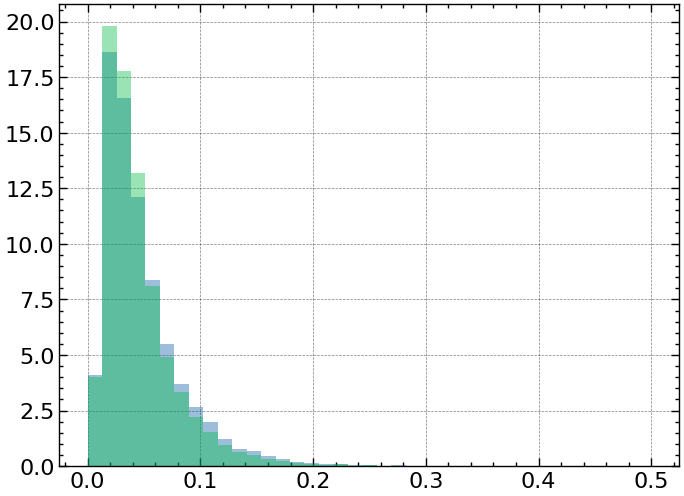

In [53]:
bins = np.linspace(0,0.5,40)
plt.hist(sys_map_quantiles[full_mask > 0], bins=bins,alpha =0.4,density=True)
plt.hist(sys_map_quantiles[gal_pix['full']], bins=bins,alpha =0.4,density=True)

In [44]:
sys_map_quantiles[gal_pix['full']]

array([0.03348967, 0.03348967, 0.03348967, ..., 0.17539211, 0.17539211,
       0.17539211], dtype='>f8')

In [55]:
wtheta_joint_bins = {}

markers = {'north': 'o', 'south': '*'}  # kept if needed later

for systematics in ['Stellar_Density_AllWISE', 'H_Alpha', 'CSFD']:
    print(f'Processing systematics: {systematics}')
    wtheta_joint_bins[systematics] = {}

    sys_map_quantiles = hp.read_map(f'{path}/full_{systematics}_nside_64.fits')
    full_mask = hp.read_map(f'{path}/full_mask_nside_64_for_systmatics_20M.fits')
    quantile_edges = np.nanpercentile(sys_map_quantiles[gal_pix['full']], np.linspace(0, 100, n_bins + 1))

    for part in ['south', 'north']:
        print(f'  Processing part: {part}')
        wtheta_joint_bins[systematics][part] = {}

        sys_map = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')

        random_pix = hp.ang2pix(
            NSIDE,
            np.radians(90.0 - randoms_part[part]['DEC']),
            np.radians(randoms_part[part]['RA']),
            nest=False
        )
        bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) - 1
        bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins - 1)

        bin_indices = np.digitize(sys_map[gal_pix[part]], bins=quantile_edges) - 1
        bin_indices = np.clip(bin_indices, 0, nbins - 1)
    
        dat = cat[part][cat[part]['DEC'] >= DEC_SPLIT] if part == 'north' else cat[part][cat[part]['DEC'] < DEC_SPLIT]

        for i in range(nbins):
            print(f'    Processing bin {i+1}/{nbins} for {part} - {systematics}')
            gal_sel = (bin_indices == i)
            rnd_sel = (bin_indices_randoms == i)

            quantile_sys = dat[gal_sel]
            quantile_sys_randoms = randoms_part[part][rnd_sel]

            if len(quantile_sys) == 0 or len(quantile_sys_randoms) == 0:
                wtheta_joint_bins[systematics][part][i] = {'theta': None, 'w_theta': None}
                continue

            theta, w_theta, sigma,cov = compute_w_theta(quantile_sys, quantile_sys_randoms, err_bars=True)
            wtheta_joint_bins[systematics][part][i] = {
                'theta': theta,
                'w_theta': w_theta,
                'sigma': sigma,
                'cov': cov,
                'edges': (quantile_edges[i], quantile_edges[i + 1]),
                'n_gal': len(quantile_sys),
                'n_rnd': len(quantile_sys_randoms),
            }


Processing systematics: Stellar_Density_AllWISE
  Processing part: south
    Processing bin 1/3 for south - Stellar_Density_AllWISE
    Processing bin 2/3 for south - Stellar_Density_AllWISE
    Processing bin 3/3 for south - Stellar_Density_AllWISE
  Processing part: north
    Processing bin 1/3 for north - Stellar_Density_AllWISE
    Processing bin 2/3 for north - Stellar_Density_AllWISE
    Processing bin 3/3 for north - Stellar_Density_AllWISE
Processing systematics: H_Alpha
  Processing part: south
    Processing bin 1/3 for south - H_Alpha
    Processing bin 2/3 for south - H_Alpha
    Processing bin 3/3 for south - H_Alpha
  Processing part: north
    Processing bin 1/3 for north - H_Alpha
    Processing bin 2/3 for north - H_Alpha
    Processing bin 3/3 for north - H_Alpha
Processing systematics: CSFD
  Processing part: south
    Processing bin 1/3 for south - CSFD
    Processing bin 2/3 for south - CSFD
    Processing bin 3/3 for south - CSFD
  Processing part: north
    Proce

In [58]:
import pickle
with open('wtheta_joint_bins.pkl', 'wb') as f:
    pickle.dump(wtheta_joint_bins, f)



In [56]:
all_edges = {
    systematics: {
        part: [
            wtheta_joint_bins[systematics][part][i].get('edges')
            for i in sorted(wtheta_joint_bins.get(systematics, {}).get(part, {}).keys())
            if wtheta_joint_bins[systematics][part][i].get('edges') is not None
        ]
        for part in wtheta_joint_bins.get(systematics, {})
    }
    for systematics in wtheta_joint_bins
}

all_edges

{'Stellar_Density_AllWISE': {'south': [(21.64236068725586, 23.91680908203125),
   (23.91680908203125, 27.727678298950195),
   (27.727678298950195, 55.51858901977539)],
  'north': [(21.64236068725586, 23.91680908203125),
   (23.91680908203125, 27.727678298950195),
   (27.727678298950195, 55.51858901977539)]},
 'H_Alpha': {'south': [(0.100006103515625, 0.6305725140412874),
   (0.6305725140412874, 1.1448432228847811),
   (1.1448432228847811, 27.272956002951656)],
  'north': [(0.100006103515625, 0.6305725140412874),
   (0.6305725140412874, 1.1448432228847811),
   (1.1448432228847811, 27.272956002951656)]},
 'CSFD': {'south': [(0.0052880015597608875, 0.027072608283103698),
   (0.027072608283103698, 0.048101499904404044),
   (0.048101499904404044, 0.7673902458402191)],
  'north': [(0.0052880015597608875, 0.027072608283103698),
   (0.027072608283103698, 0.048101499904404044),
   (0.048101499904404044, 0.7673902458402191)]}}

In [79]:
# Quick check — what fraction of randoms fall outside your mask?
rand_pix = hp.ang2pix(64,
               np.radians(90.0 - randoms_part['south']['DEC']),
               np.radians(randoms_part['south']['RA']),
               nest=False)
mask = hp.read_map(f'{path}/south_mask_nside_64_for_systmatics_20M.fits')
outside = (mask[rand_pix] == 0).sum()
print(f"Randoms outside mask: {outside:,} / {len(rand_pix):,} ({100*outside/len(rand_pix):.2f}%)")

Randoms outside mask: 37 / 55,887,774 (0.00%)


In [75]:
[wtheta_joint_bins['Stellar_Density_AllWISE']['south'][i]['n_rnd']/1248.9393237847612 for i in sorted(wtheta_joint_bins['Stellar_Density_AllWISE']['south'].keys())]

[15289.613063133016, 14181.481568156953, 15277.095241248264]

In [ ]:
for systematics in ['Stellar_Density_AllWISE', 'H_Alpha', 'CSFD']:
    print(f'\n=== {systematics} ===')

    fig = plt.figure(figsize=(6.0 * nbins, 10))

    part_maps = {}
    part_edges = {}

    for part in ['south', 'north']:
        sys_map_part = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')
        gal_values = sys_map_part[gal_pix[part]]
        valid_values = np.isfinite(gal_values) & (gal_values > -1e20)
        quantile_edges = np.nanpercentile(gal_values[valid_values], np.linspace(0, 100, nbins + 1))
        part_edges[part] = quantile_edges

        bin_indices = np.digitize(gal_values, bins=quantile_edges) - 1
        bin_indices = np.clip(bin_indices, 0, nbins - 1)

        part_maps[part] = []
        for i in range(nbins):
            quantile_gal = cat[part][bin_indices == i]
            sky_map = points_to_map(quantile_gal['RA'], quantile_gal['DEC'], nside=64)
            part_maps[part].append((sky_map, quantile_gal))

    nonzero_maps = []
    for part in ['south', 'north']:
        for sky_map, _ in part_maps[part]:
            if np.any(sky_map > 0):
                nonzero_maps.append(sky_map[sky_map > 0])

    vmax = max(np.max(m) for m in nonzero_maps) if nonzero_maps else 1.0

    for row, part in enumerate(['south', 'north']):
        edges = part_edges[part]
        for col in range(nbins):
            sky_map, quantile_gal = part_maps[part][col]
            sky_map = np.where(sky_map > 0, sky_map, hp.UNSEEN)

            title = (
                f'{part.title()} Q{col + 1} '
                f'[{edges[col]:.3g}, {edges[col + 1]:.3g}] '
                f'N={len(quantile_gal)}'
            )

            hp.mollview(
                sky_map,
                fig=fig.number,
                sub=(2, nbins, row * nbins + col + 1),
                title=title,
                unit='Galaxies per pixel',
                min=0,
                max=vmax,
                cmap='viridis',
                cbar=True,
                notext=False,
                norm='hist',
            )
            hp.graticule()

    fig.suptitle(f'Galaxy sky distribution by quantile bin: {systematics}', y=0.98)
    plt.tight_layout()
    plt.show()

south - Quantile 1: [22.19, 24.20] -> 127178 objects with density 10.44 objects/deg^2
south - Quantile 2: [24.20, 28.45] -> 118433 objects with density 9.72 objects/deg^2
south - Quantile 3: [28.45, 53.10] -> 85210 objects with density 7.00 objects/deg^2
north - Quantile 1: [22.19, 24.20] -> 44465 objects with density 8.62 objects/deg^2
north - Quantile 2: [24.20, 28.45] -> 44031 objects with density 8.54 objects/deg^2
north - Quantile 3: [28.45, 53.10] -> 53244 objects with density 10.33 objects/deg^2


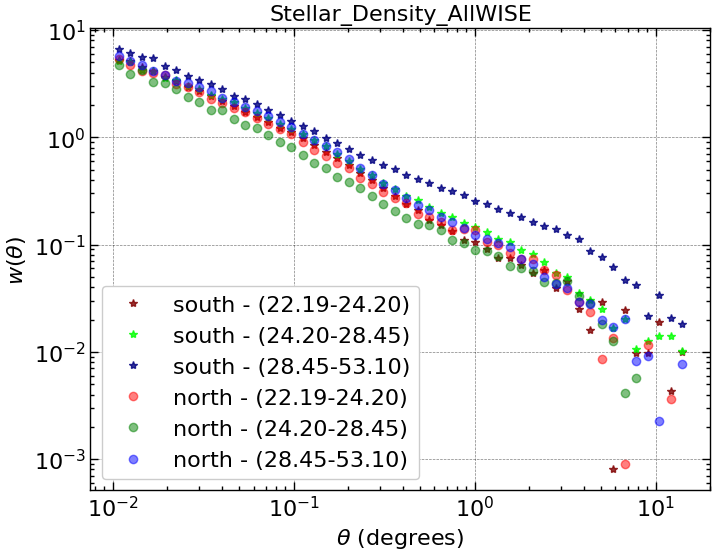

south - Quantile 1: [0.10, 0.55] -> 70411 objects with density 5.78 objects/deg^2
south - Quantile 2: [0.55, 0.98] -> 109484 objects with density 8.99 objects/deg^2
south - Quantile 3: [0.98, 12.49] -> 150926 objects with density 12.39 objects/deg^2
north - Quantile 1: [0.10, 0.55] -> 44899 objects with density 8.71 objects/deg^2
north - Quantile 2: [0.55, 0.98] -> 46501 objects with density 9.02 objects/deg^2
north - Quantile 3: [0.98, 12.49] -> 50340 objects with density 9.76 objects/deg^2


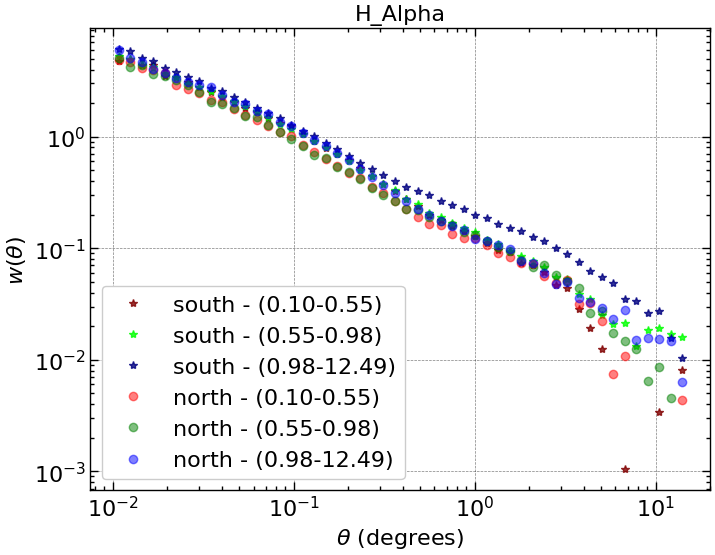

south - Quantile 1: [0.01, 0.02] -> 16125 objects with density 1.32 objects/deg^2
south - Quantile 2: [0.02, 0.04] -> 144857 objects with density 11.89 objects/deg^2
south - Quantile 3: [0.04, 0.51] -> 169839 objects with density 13.94 objects/deg^2
north - Quantile 1: [0.01, 0.02] -> 45179 objects with density 8.76 objects/deg^2
north - Quantile 2: [0.02, 0.04] -> 45156 objects with density 8.76 objects/deg^2
north - Quantile 3: [0.04, 0.51] -> 51405 objects with density 9.97 objects/deg^2


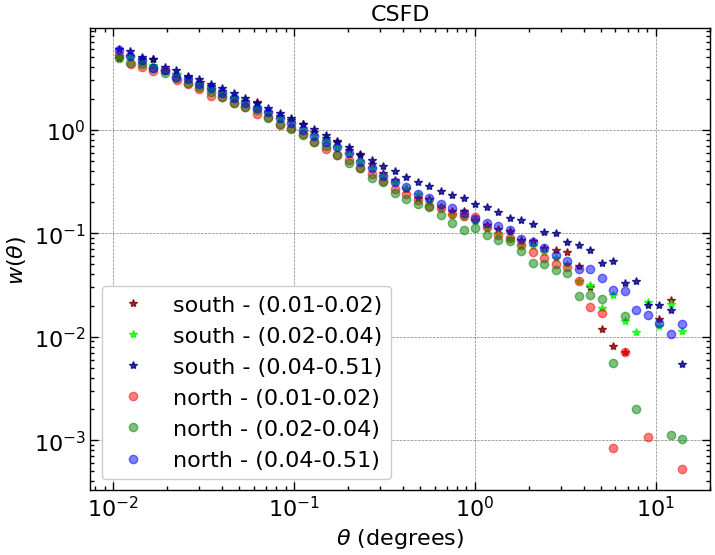

In [ ]:
# markers = {'north': 'o', 'south': '*'}
# for systematics in ['Stellar_Density_AllWISE','H_Alpha','CSFD']:

#     sys_map_quantiles = hp.read_map(f'{path}/full_{systematics}_nside_64.fits')
#     quantile_edges = np.nanpercentile(sys_map_quantiles[mask>0], np.linspace(0, 100, n_bins + 1))

#     plt.figure(figsize=(10,8))
#     for part in ['south','north']: 
        
#         mask = hp.read_map(f'{path}/{part}_mask_nside_64_for_systmatics_20M.fits')

#         #sys_map = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')
#         #quantile_edges = np.nanpercentile(sys_map_quantiles[mask>0], np.linspace(0, 100, n_bins + 1))
#         sys_map = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')
#         random_pix  = hp.ang2pix(64, np.radians(90.0 - randoms_part[part]['DEC']), np.radians(randoms_part[part]['RA']), nest=False)
#         bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
#         bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
#         bin_mask_randoms_64 = {}
        

#         bin_indices = np.digitize(sys_map[gal_pix[part]], bins=quantile_edges) -1
#         bin_indices = np.clip(bin_indices, 0, nbins-1)
#         bin_mask_64 = {}

#         for i in np.unique(bin_indices):
#             bin_mask_64[i] = bin_indices == i
#         for i in np.unique(bin_indices_randoms):
#             bin_mask_randoms_64[i] = bin_indices_randoms == i

#         dat = cat[part][cat[part]['DEC']>=32.375] if part=='north' else cat[part][cat[part]['DEC']<32.375]
#         #dat = dat[mask>0]
#         quantile_sys = {}
#         quantile_sys_randoms = {}
        
#         if part=='north':
#             alpha = 0.5
#             colors= ['red','green','blue']
#         else:
#             alpha = 0.8
#             colors = ['maroon','lime','navy']
#         for i in np.unique(bin_indices):
#             quantile_sys_randoms[i] = randoms_part[part][bin_mask_randoms_64[i]]
#             quantile_sys[i] = dat[bin_mask_64[i]]
#             pix = points_to_map(quantile_sys[i]['RA'], quantile_sys[i]['DEC'], nside=64)
#             theta, w_theta = compute_w_theta(quantile_sys[i], quantile_sys_randoms[i],err_bars = True)
#             plt.loglog(theta, w_theta[0], label=f'{part} - ({quantile_edges[i]:.2f}-{quantile_edges[i+1]:.2f})',ls='None',marker=markers[part], color=colors[i],alpha = alpha)
#             print(f'{part} - Quantile {i+1}: [{quantile_edges[i]:.2f}, {quantile_edges[i+1]:.2f}] -> {len(quantile_sys[i])} objects with density {len(quantile_sys[i])/area[part]:.2f} objects/deg^2')
#     plt.xscale('log')
#     plt.title(f'{systematics}')
#     plt.yscale('log')
#     plt.xlabel(r'$\theta$ (degrees)')
#     plt.ylabel(r'$w(\theta)$')
#     plt.legend()
#     plt.show()

## Strategy #2 independent bins


In [ ]:
wtheta_split_bins = {}

markers = {'north': 'o', 'south': '*'}  # kept if needed later

for systematics in ['Stellar_Density_AllWISE', 'H_Alpha', 'CSFD','Saggitarius_Density']:
    print(f'Processing systematics: {systematics}')
    wtheta_split_bins[systematics] = {}

    #sys_map_quantiles = hp.read_map(f'{path}/full_{systematics}_nside_64.fits')
    #full_mask = hp.read_map(f'{path}/full_mask_nside_64_for_systmatics_20M.fits')
    #quantile_edges = np.nanpercentile(sys_map_quantiles[full_mask > 0], np.linspace(0, 100, n_bins + 1))
    
    for part in ['south', 'north']:
        print(f'  Processing part: {part}')
        wtheta_split_bins[systematics][part] = {}

        sys_map = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')
        mask = hp.read_map(f'{path}/{part}_mask_nside_64_for_systmatics_20M.fits')
        quantile_edges = np.nanpercentile(sys_map[gal_pix[part]], np.linspace(0, 100, n_bins + 1))
        
        random_pix = hp.ang2pix(
            NSIDE,
            np.radians(90.0 - randoms _part[part]['DEC']),
            np.radians(randoms_part[part]['RA']),
            nest=False
        )
        bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) - 1
        bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins - 1)

        bin_indices = np.digitize(sys_map[gal_pix[part]], bins=quantile_edges) - 1
        bin_indices = np.clip(bin_indices, 0, nbins - 1)

        dat = cat[part][cat[part]['DEC'] >= DEC_SPLIT] if part == 'north' else cat[part][cat[part]['DEC'] < DEC_SPLIT]

        for i in range(nbins):
            print(f'    Processing bin {i+1}/{nbins} for {part} - {systematics}')
            gal_sel = (bin_indices == i)
            rnd_sel = (bin_indices_randoms == i)

            quantile_sys = dat[gal_sel]
            quantile_sys_randoms = randoms_part[part][rnd_sel]

            if len(quantile_sys) == 0 or len(quantile_sys_randoms) == 0:
                wtheta_split_bins[systematics][part][i] = {'theta': None, 'w_theta': None}
                continue

            theta, w_theta, sigma,cov = compute_w_theta(quantile_sys, quantile_sys_randoms, err_bars=True)
            wtheta_split_bins[systematics][part][i] = {
                'theta': theta,
                'w_theta': w_theta,
                'sigma': sigma,
                'cov': cov,
                'edges': (quantile_edges[i], quantile_edges[i + 1]),
                'n_gal': len(quantile_sys),
                'n_rnd': len(quantile_sys_randoms),
            }


Processing systematics: Stellar_Density_AllWISE
  Processing part: south
    Processing bin 1/3 for south - Stellar_Density_AllWISE
    Processing bin 2/3 for south - Stellar_Density_AllWISE
    Processing bin 3/3 for south - Stellar_Density_AllWISE
  Processing part: north
    Processing bin 1/3 for north - Stellar_Density_AllWISE
    Processing bin 2/3 for north - Stellar_Density_AllWISE
    Processing bin 3/3 for north - Stellar_Density_AllWISE
Processing systematics: H_Alpha
  Processing part: south
    Processing bin 1/3 for south - H_Alpha
    Processing bin 2/3 for south - H_Alpha
    Processing bin 3/3 for south - H_Alpha
  Processing part: north
    Processing bin 1/3 for north - H_Alpha
    Processing bin 2/3 for north - H_Alpha
    Processing bin 3/3 for north - H_Alpha
Processing systematics: CSFD
  Processing part: south
    Processing bin 1/3 for south - CSFD
    Processing bin 2/3 for south - CSFD
    Processing bin 3/3 for south - CSFD
  Processing part: north
    Proce

In [81]:
import pickle
with open('wtheta_split_bins.pkl', 'wb') as f:
    pickle.dump(wtheta_split_bins, f)

In [36]:
3.2+ 1.4

4.6


=== Stellar_Density_AllWISE ===

SOUTH:
  Q1: [21.6424, 23.796] | Ngal=110269, Nrnd=18160328 | rho_gal=27.86, rho_rnd=4588.66 deg^-2
  Q2: [23.796, 27.1913] | Ngal=110268, Nrnd=17047950 | rho_gal=29.68, rho_rnd=4588.66 deg^-2
  Q3: [27.1913, 55.5186] | Ngal=110284, Nrnd=20679496 | rho_gal=24.47, rho_rnd=4588.66 deg^-2

NORTH:
  Q1: [22.1871, 24.3749] | Ngal=47222, Nrnd=8529291 | rho_gal=25.44, rho_rnd=4594.76 deg^-2
  Q2: [24.3749, 29.5145] | Ngal=47249, Nrnd=8500999 | rho_gal=25.54, rho_rnd=4594.76 deg^-2
  Q3: [29.5145, 52.6612] | Ngal=47269, Nrnd=6659046 | rho_gal=32.62, rho_rnd=4594.76 deg^-2


/tmp/ipykernel_1136288/3547952287.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


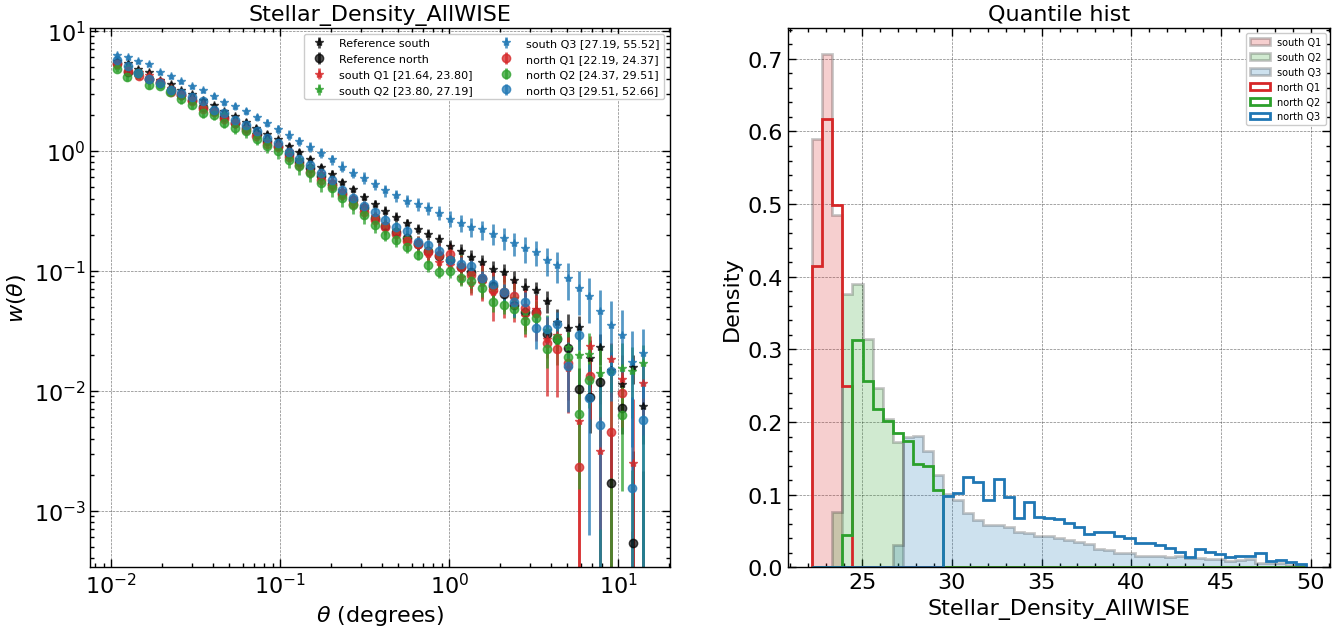


=== H_Alpha ===

SOUTH:
  Q1: [0.107431, 0.68275] | Ngal=110244, Nrnd=16985970 | rho_gal=29.78, rho_rnd=4588.66 deg^-2
  Q2: [0.68275, 1.20123] | Ngal=110278, Nrnd=17554914 | rho_gal=28.83, rho_rnd=4588.66 deg^-2
  Q3: [1.20123, 27.273] | Ngal=110299, Nrnd=21346890 | rho_gal=23.71, rho_rnd=4588.66 deg^-2

NORTH:
  Q1: [0.100006, 0.556475] | Ngal=47235, Nrnd=8414900 | rho_gal=25.79, rho_rnd=4594.76 deg^-2
  Q2: [0.556475, 1.01591] | Ngal=47251, Nrnd=8185499 | rho_gal=26.52, rho_rnd=4594.76 deg^-2
  Q3: [1.01591, 7.96779] | Ngal=47254, Nrnd=7088937 | rho_gal=30.63, rho_rnd=4594.76 deg^-2


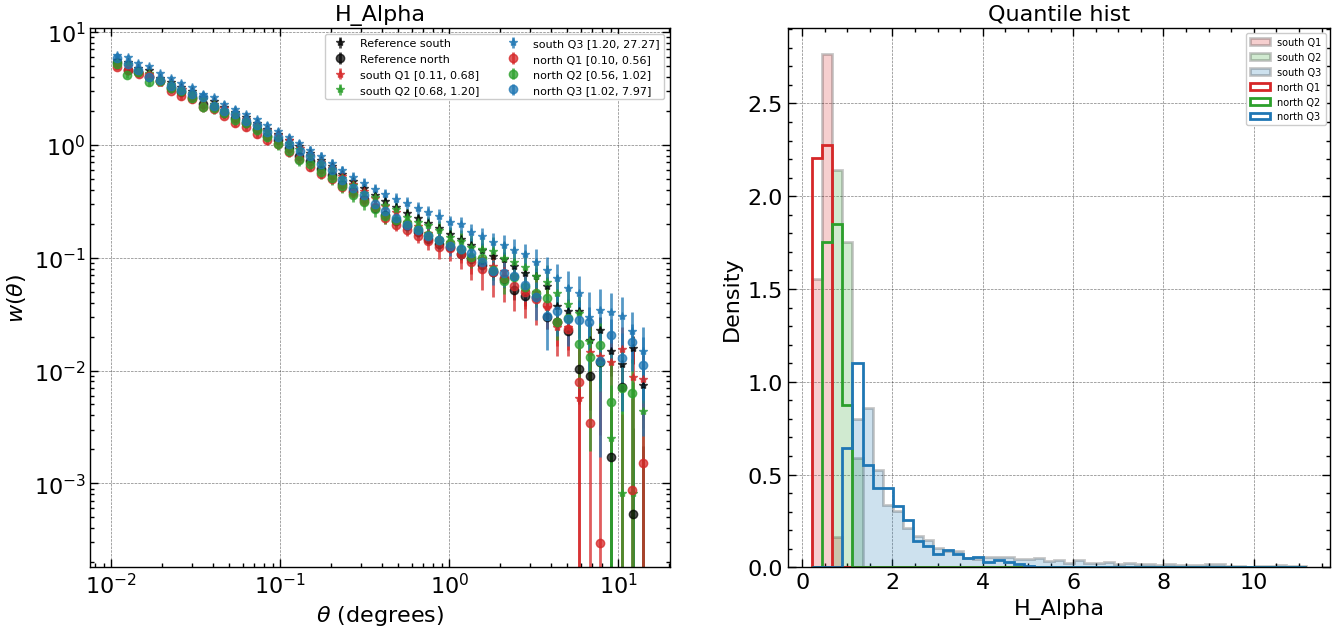


=== CSFD ===

SOUTH:
  Q1: [0.00806435, 0.031034] | Ngal=110265, Nrnd=17426296 | rho_gal=29.03, rho_rnd=4588.66 deg^-2
  Q2: [0.031034, 0.0506544] | Ngal=110269, Nrnd=17134559 | rho_gal=29.53, rho_rnd=4588.66 deg^-2
  Q3: [0.0506544, 0.76739] | Ngal=110287, Nrnd=21326919 | rho_gal=23.73, rho_rnd=4588.66 deg^-2

NORTH:
  Q1: [0.005288, 0.0176399] | Ngal=47242, Nrnd=8469177 | rho_gal=25.63, rho_rnd=4594.76 deg^-2
  Q2: [0.0176399, 0.0419223] | Ngal=47233, Nrnd=8287135 | rho_gal=26.19, rho_rnd=4594.76 deg^-2
  Q3: [0.0419223, 0.281864] | Ngal=47265, Nrnd=6933024 | rho_gal=31.32, rho_rnd=4594.76 deg^-2


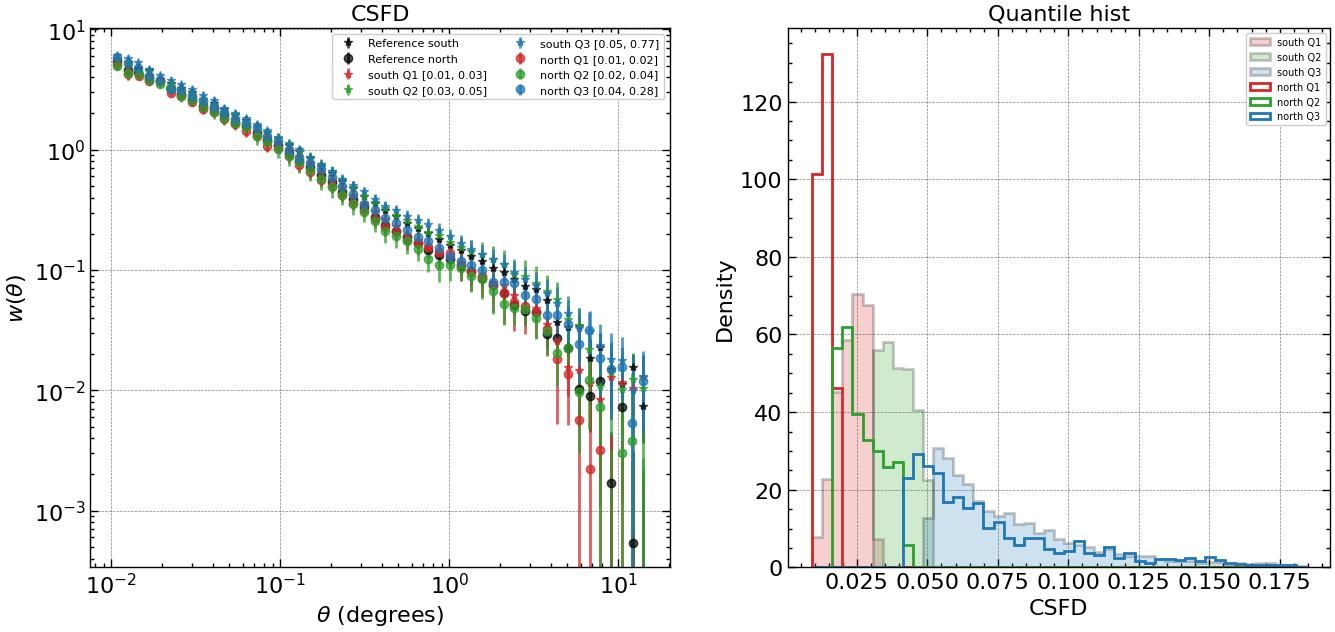


=== Saggitarius_Density ===

SOUTH:
  Q1: [-4.458e-11, 0.000102496] | Ngal=110274, Nrnd=20339370 | rho_gal=24.88, rho_rnd=4588.66 deg^-2
  Q2: [0.000102496, 0.685507] | Ngal=110240, Nrnd=17752265 | rho_gal=28.50, rho_rnd=4588.66 deg^-2
  Q3: [0.685507, 32.6997] | Ngal=110307, Nrnd=17796139 | rho_gal=28.44, rho_rnd=4588.66 deg^-2

NORTH:
  Q1: [-7.10269e-05, -9.42479e-12] | Ngal=47243, Nrnd=7756467 | rho_gal=27.99, rho_rnd=4594.76 deg^-2
  Q2: [-9.42479e-12, 6.90557e-08] | Ngal=47190, Nrnd=7656965 | rho_gal=28.32, rho_rnd=4594.76 deg^-2
  Q3: [6.90557e-08, 0.832199] | Ngal=47307, Nrnd=8275904 | rho_gal=26.26, rho_rnd=4594.76 deg^-2


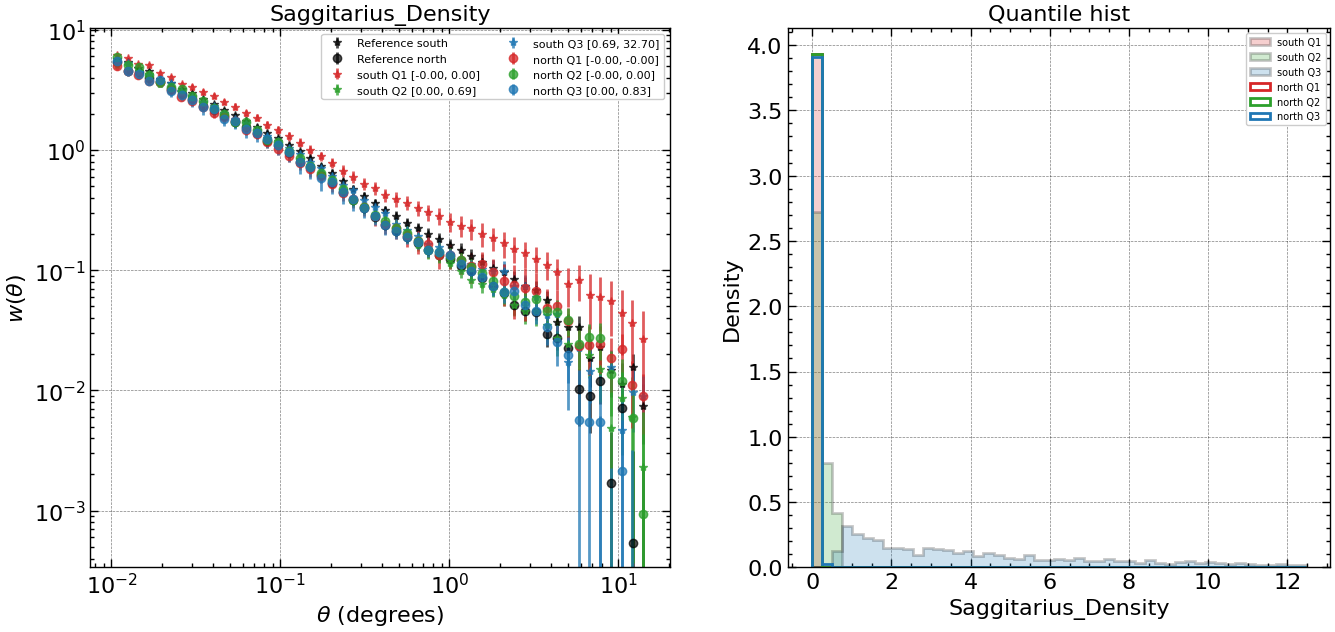

In [83]:
markers = {'north': 'o', 'south': '*'}
colors = ['tab:red', 'tab:green', 'tab:blue']

for systematics in ['Stellar_Density_AllWISE', 'H_Alpha', 'CSFD', 'Saggitarius_Density']:
    print(f"\n=== {systematics} ===")

    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.2, 3.0], wspace=0.21)
    ax = fig.add_subplot(gs[0, 0])      # w(theta)
    ax_hist = fig.add_subplot(gs[0, 1]) # side histogram
    ax.errorbar(w_ref_south_weights[0], w_ref_south_weights[1], yerr=w_ref_south_weights[2],
                 ls='None', marker='*', color='black', label='Reference south',alpha =0.7)
    ax.errorbar(w_ref_north_weights[0], w_ref_north_weights[1], yerr=w_ref_north_weights[2],
                 ls='None', marker='o', color='k', label='Reference north',alpha=0.7)
    sys_map_quantiles = hp.read_map(f'{path}/full_{systematics}_nside_64.fits')
    full_mask = hp.read_map(f'{path}/full_mask_nside_64_for_systmatics_20M.fits')
    bins = np.linspace(np.nanpercentile(sys_map_quantiles[full_mask > 0], 1), np.nanpercentile(sys_map_quantiles[full_mask > 0], 99), 50)
    for part in ['south', 'north']:
        print(f"\n{part.upper()}:")

        # values for side histogram
        sys_map_part = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')
        sys_vals = sys_map_part[gal_pix[part]]
        valid_vals = np.isfinite(sys_vals) & (sys_vals > -1e20)

        for i in range(nbins):
            entry = wtheta_split_bins.get(systematics, {}).get(part, {}).get(i, None)

            if entry is None or entry.get('theta') is None:
                print(f"  Q{i+1}: no data")
                continue

            theta = np.asarray(entry['theta'])
            w = np.asarray(entry['w_theta'])
            if w.ndim > 1:
                w = w[0]

            sigma = entry.get('sigma', None)
            if sigma is not None:
                sigma = np.asarray(sigma)
                if sigma.ndim > 1:
                    sigma = sigma[0]

            qmin, qmax = entry.get('edges', (np.nan, np.nan))
            n_gal = entry.get('n_gal', 0)
            n_rnd = entry.get('n_rnd', 0)

            # gal_density = n_gal / area[part]
            # rnd_density = n_rnd / area[part]
                       
            area_quantile = n_rnd / density_randoms[part]
            gal_density = n_gal / area_quantile
            rnd_density = n_rnd / area_quantile
            print(
                f"  Q{i+1}: [{qmin:.6g}, {qmax:.6g}] | "
                f"Ngal={n_gal}, Nrnd={n_rnd} | "
                f"rho_gal={gal_density:.2f}, rho_rnd={rnd_density:.2f} deg^-2"
            )

            # left panel: w(theta)
            ax.errorbar(
                theta, w, yerr=sigma,
                fmt=markers[part], ls='None',
                color=colors[i], alpha=0.75,
                label=f"{part} Q{i+1} [{qmin:.2f}, {qmax:.2f}]"
            )

            # right panel: histogram per quantile
            in_q = valid_vals & (sys_vals >= qmin)
            in_q &= (sys_vals <= qmax) if (i == nbins - 1) else (sys_vals < qmax)
            ax_hist.hist(
                sys_vals[in_q],
                bins=bins,
                density=True,
                edgecolor = 'k' if part =='south' else colors[i],
                color=colors[i],
                alpha=0.22 if part == 'south' else 1.0,
                histtype='stepfilled' if part == 'south' else 'step',
                linewidth=2.0,
                label=f"{part} Q{i+1}"
            )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\theta$ (degrees)')
    ax.set_ylabel(r'$w(\theta)$')
    ax.set_title(systematics)
    ax.legend(fontsize=8, ncol=2)

    ax_hist.set_title('Quantile hist')
    ax_hist.set_xlabel(systematics)
    ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


=== Stellar_Density_AllWISE ===


/tmp/ipykernel_1136288/3962440898.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


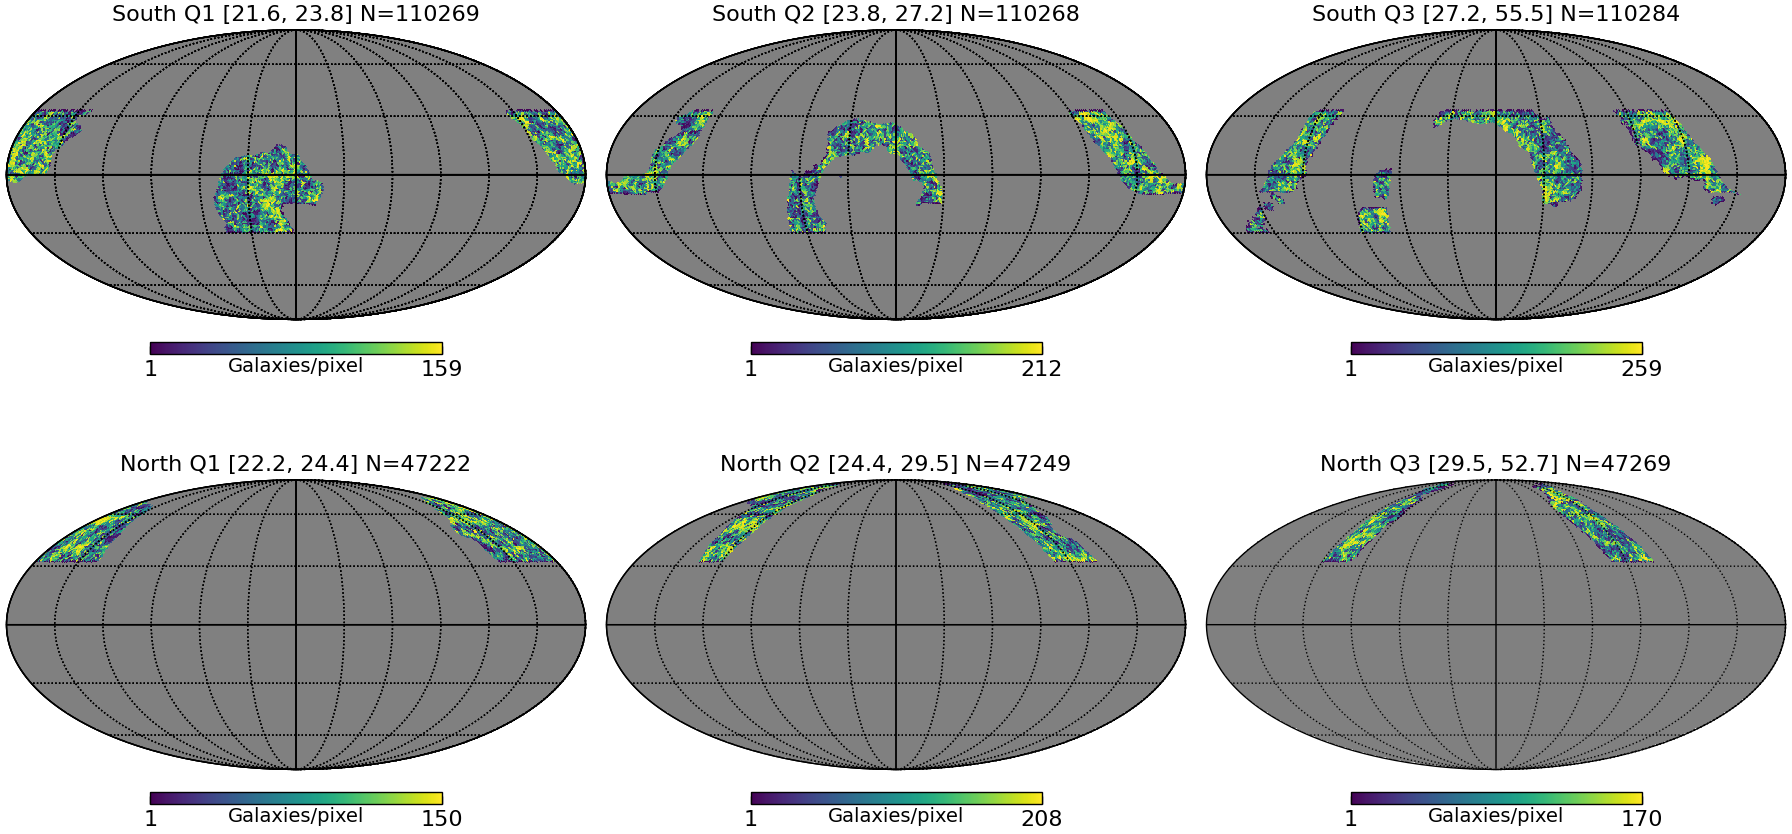


=== H_Alpha ===


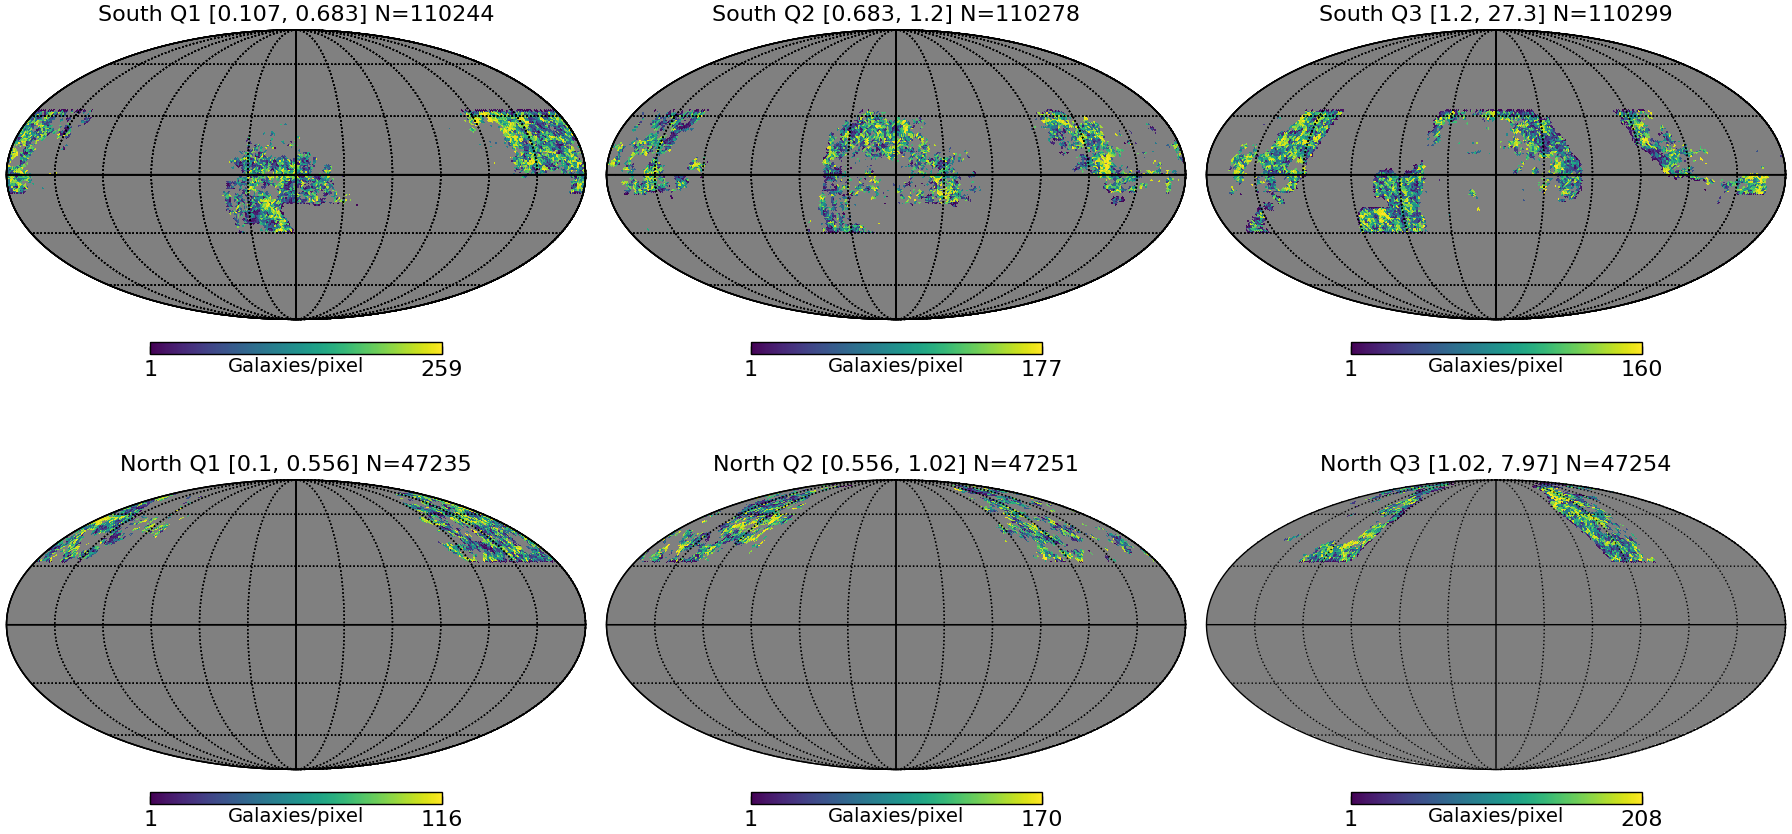


=== CSFD ===


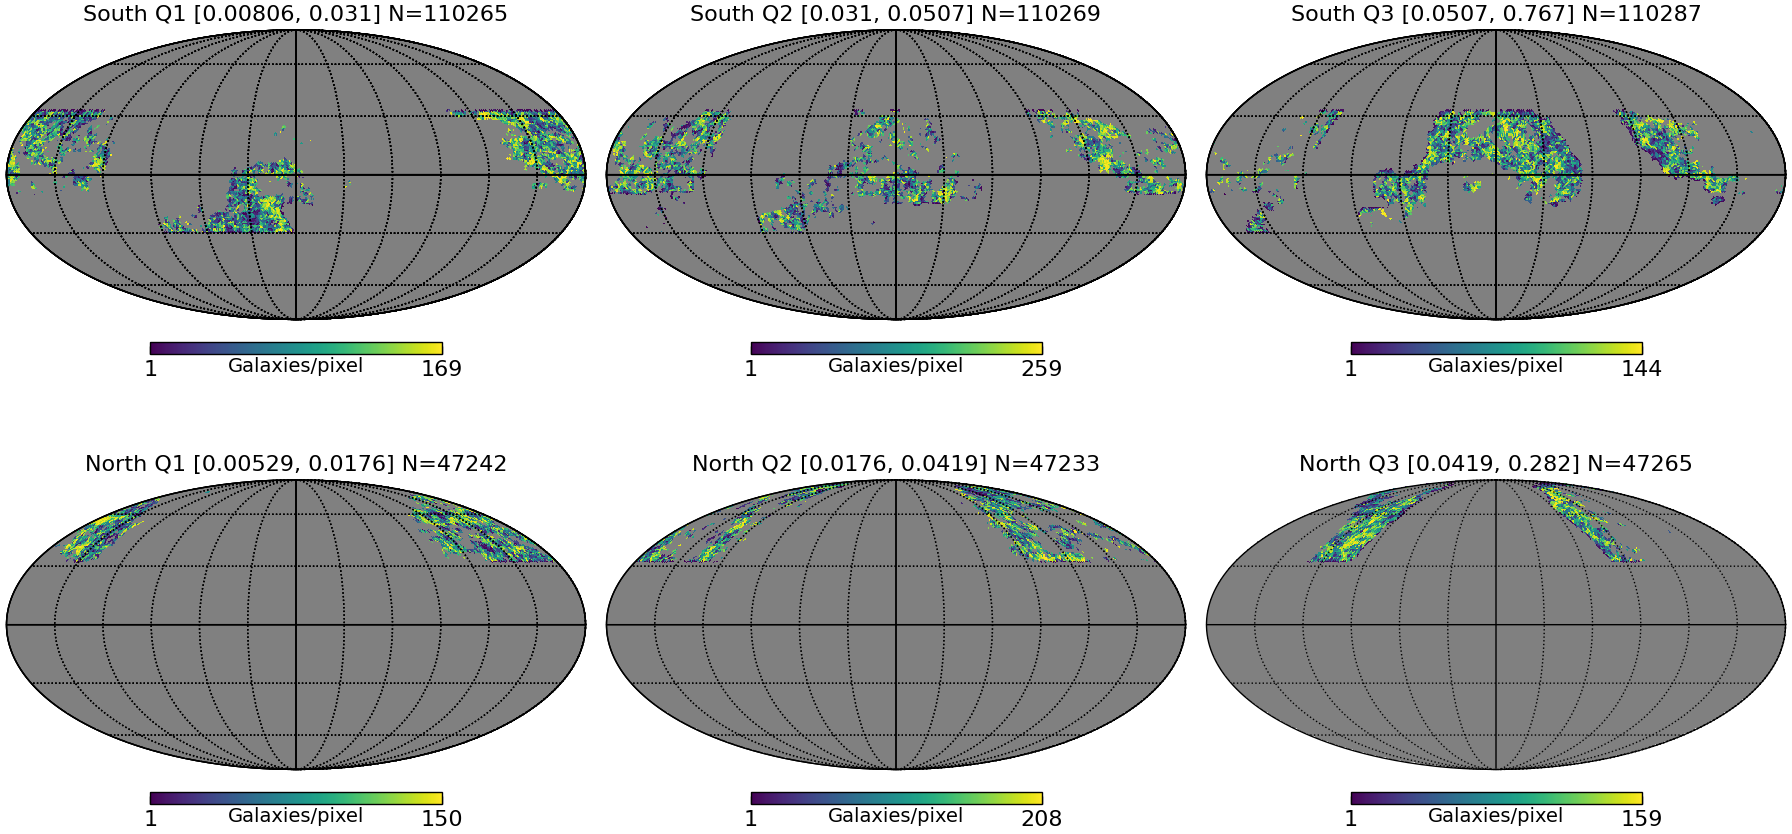


=== Saggitarius_Density ===


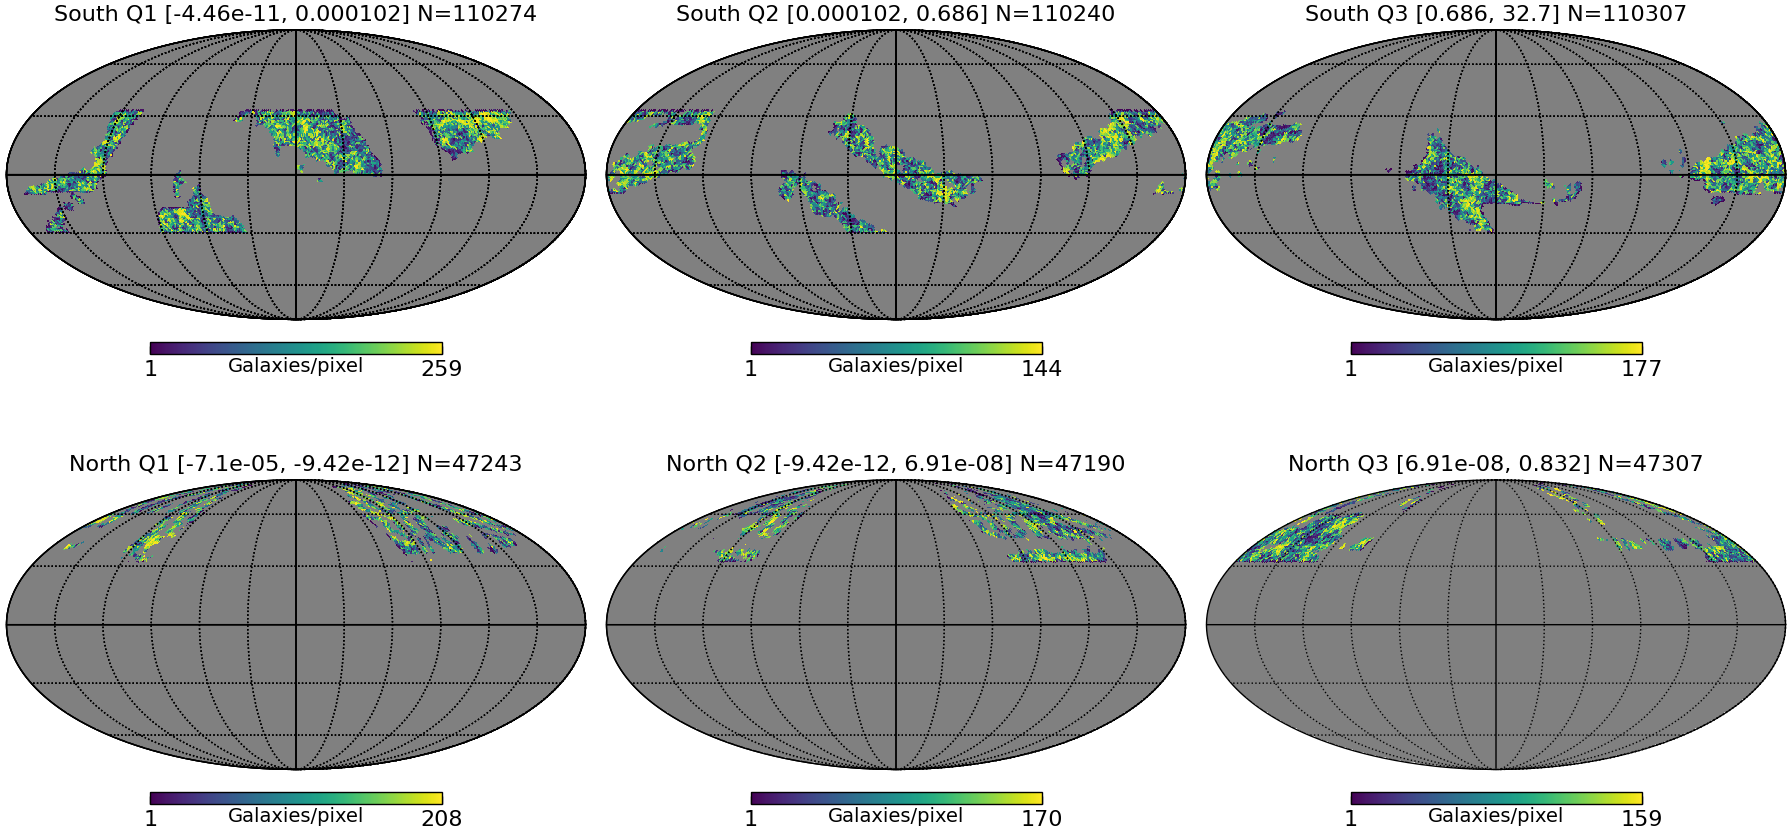

In [88]:
# Healpy map view of all quantiles (galaxy density per pixel)

systems_to_plot = ['Stellar_Density_AllWISE', 'H_Alpha', 'CSFD', 'Saggitarius_Density']

for systematics in systems_to_plot:
    print(f'\n=== {systematics} ===')
    fig = plt.figure(figsize=(6 * nbins, 9))

    for row, part in enumerate(['south', 'north']):
        sys_map = hp.read_map(f'{path}/{part}_{systematics}_nside_64.fits')

        # quantiles defined on galaxy-sampled pixels (same strategy as your split bins)
        vals = sys_map[gal_pix[part]]
        good = np.isfinite(vals) & (vals > -1e20)
        quantile_edges = np.nanpercentile(vals[good], np.linspace(0, 100, nbins + 1))

        bin_idx = np.digitize(vals, bins=quantile_edges) - 1
        bin_idx = np.clip(bin_idx, 0, nbins - 1)

        dat = cat[part]  # already DEC-split in your notebook

        for i in range(nbins):
            qsel = (bin_idx == i)
            qcat = dat[qsel]

            m = points_to_map(qcat['RA'], qcat['DEC'], nside=64)
            m = np.where(m > 0, m, hp.UNSEEN)

            hp.mollview(
                m,
                fig=fig.number,
                sub=(2, nbins, row * nbins + i + 1),
                title=f"{part.title()} Q{i+1} [{quantile_edges[i]:.3g}, {quantile_edges[i+1]:.3g}] N={len(qcat)}",
                unit='Galaxies/pixel',
                cmap='viridis',
                norm='hist',
                cbar=True
            )
            hp.graticule()

    plt.tight_layout()
    plt.show()


In [ ]:
sys_part = {}
for systematics in ['Stellar_Density_AllWISE','H_Alpha','CSFD']:
    sys_map = hp.read_map(f'{path}/full_{systematics}_nside_64.fits')
    sys_part[systematics] = {}

    for part in ['north','south']:
        sys_part[systematics][part] = sys_map[gal_pix[part]]
        


In [27]:
pct_low = 2
pct_high = 98
lower = max(np.percentile(sys_part[part], pct_low) for part in ['north','south'])
upper = min(np.percentile(sys_part[part], pct_high) for part in ['north','south'])
print(f'North range: [{sys_part["north"].min():.6g}, {sys_part["north"].max():.6g}]')
print(f'South range: [{sys_part["south"].min():.6g}, {sys_part["south"].max():.6g}]')
print(f'Trimmed range: [{lower:.6g}, {upper:.6g}]')


North range: [0.005288, 0.281864]
South range: [0.00806435, 0.76739]
Common range: [0.0142932, 0.13769]


Text(0.5, 0, 'Systematic Value')

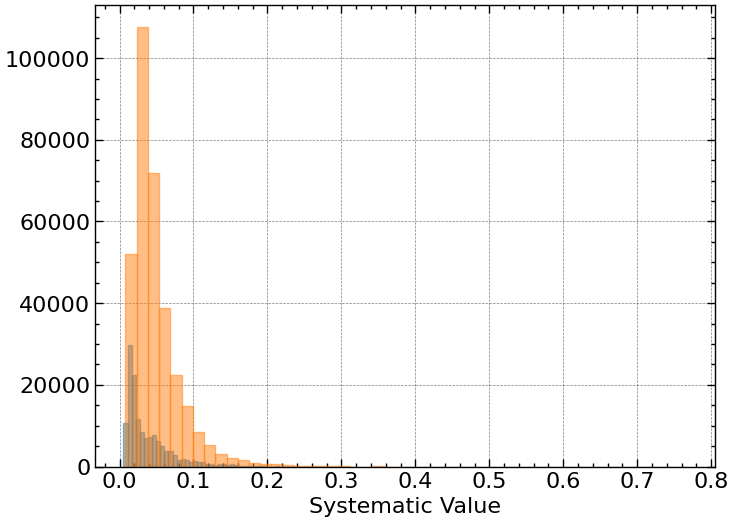

In [30]:
plt.hist(sys_part['north'], bins=50, alpha=0.5, label='North', color='tab:blue', edgecolor='tab:blue')
plt.hist(sys_part['south'], bins=50, alpha=0.5, label='South', color='tab:orange', edgecolor='tab:orange')
plt.xlabel('Systematic Value')  

Text(0.5, 0, 'Systematic Value')

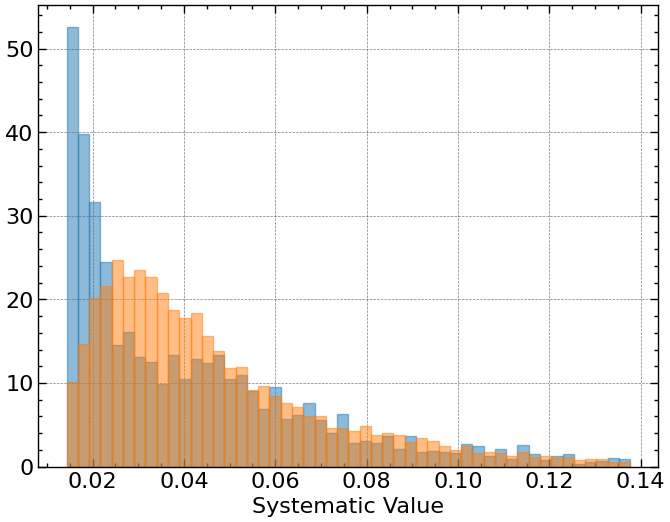

In [31]:
plt.hist(sys_part['north'], bins=50, range=(lower, upper), alpha=0.5, label='North', color='tab:blue', edgecolor='tab:blue',density=True)
plt.hist(sys_part['south'], bins=50, range=(lower, upper), alpha=0.5, label='South', color='tab:orange', edgecolor='tab:orange',density=True)
plt.xlabel('Systematic Value')  

In [ ]:
colors= ['r','k']
for sys_name in systematics_list:
    
    for survey in ['north','south']:
        sys_map = hp.read_map(f'{path}/{survey}_{sys_name}_nside_64.fits')
        mask =hp.read_map(f'{path}/{survey}_mask_nside_64_for_systmatics_20M.fits')
        #randoms_counts = hp.read_map(f'{path}/{survey}_counts_randoms_nside_64.fits')
        data  =sys_map[mask>0]
        #quantiles = np.nanpercentile(data, np.linspace(0, 100, n_bins + 1))
        quantile_edges = quantiles_sys[sys_name]
        quantile_counts, edges = np.histogram(data, bins=quantile_edges)

        random_pix  = hp.ang2pix(64, np.radians(90.0 - randoms_part[survey]['DEC']), np.radians(randoms_part[survey]['RA']), nest=False)
        bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
        bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
        number_randoms_in_bins = np.bincount(bin_indices_randoms, minlength=nbins)
        print(f"\n{survey} - {sys_name}")
        area_quantile = number_randoms_in_bins / density_randoms[survey]
        for i, c in enumerate(quantile_counts):
            print(f"Q{i+1}: [{quantile_edges[i]:.6g}, {quantile_edges[i+1]:.6g}) -> {c} objects with density {c/area_quantile[i]:.2f} objects/deg^2")
        plt.hist(data, bins=bins_sys[sys_name], alpha=0.5, label=f'{survey} - {sys_name}',density=True,color=colors[0] if survey=='north' else colors[1],edgecolor=colors[0] if survey=='north' else colors[1])
        
        plt.title(f'{sys_name} Distribution')
        plt.xlabel(sys_name)
        plt.ylabel('Frequency')
        plt.legend()
    plt.show()


In [54]:
dat_north = cat['north'][cat['north']['DEC']>=32.375]
dat_south = cat['south'][cat['south']['DEC']<32.375]


In [55]:
len(dat_north)/area['north'], len(dat_south)/area['south']

(27.49110234006032, 27.159797513082342)

In [90]:
n_bins = 3
bins_sys= {}
quantiles_sys = {}
for sys_name in systematics_list:
    sys_map = systematics_maps[sys_name]
    data  =sys_map[mask>0]
    quantiles = np.nanpercentile(data, np.linspace(1, 99, n_bins + 1))
    quantiles_sys[sys_name] = quantiles
    bins_sys[sys_name] = np.linspace(np.nanpercentile(data, 0.1), np.nanpercentile(data, 99.9),60)
    print(f'{sys_name} quantiles: {quantiles}')

H_Alpha quantiles: [ 0.27155513  0.73047872  1.33600349 13.07426818]
Saggitarius_Density quantiles: [-1.45823598e-11  2.12532065e-07  5.49402762e-01  1.43920029e+01]
Stellar_Density_AllWISE quantiles: [22.13858925 23.94749424 28.10457471 50.24800591]
CSFD quantiles: [0.01251891 0.03258665 0.05580566 0.18579874]
PSFDEPTH_Z quantiles: [22.38497758 23.2115268  23.36361323 23.99158372]
PSFDEPTH_G quantiles: [24.0586397  24.6996907  24.83367154 25.30901615]
PSFDEPTH_R quantiles: [23.57711002 24.12859714 24.25773181 25.12828967]
PSFSIZE_G quantiles: [1.2111861  1.4328707  1.56948071 1.94331121]
PSFSIZE_R quantiles: [1.09458607 1.29245056 1.44290051 1.84559187]
PSFSIZE_Z quantiles: [0.95050589 1.21027023 1.37092942 1.79432225]
PSFDEPTH_W1 quantiles: [21.22577554 21.32690504 21.39055004 21.56922707]


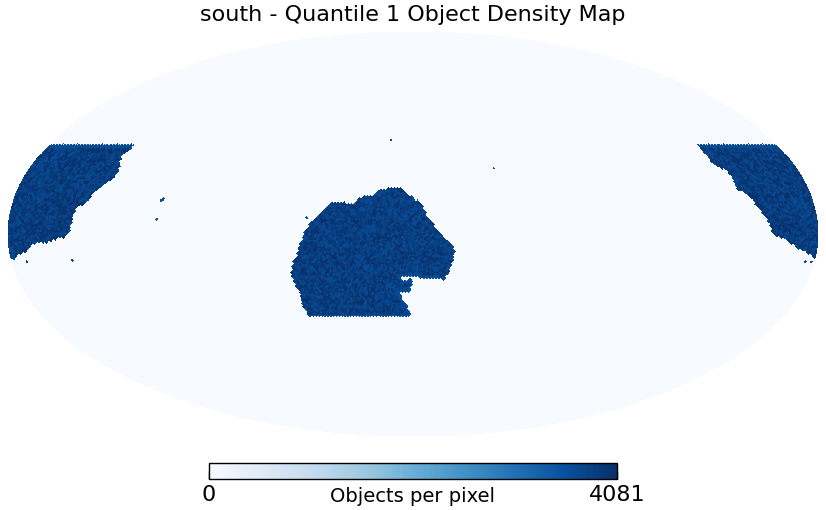

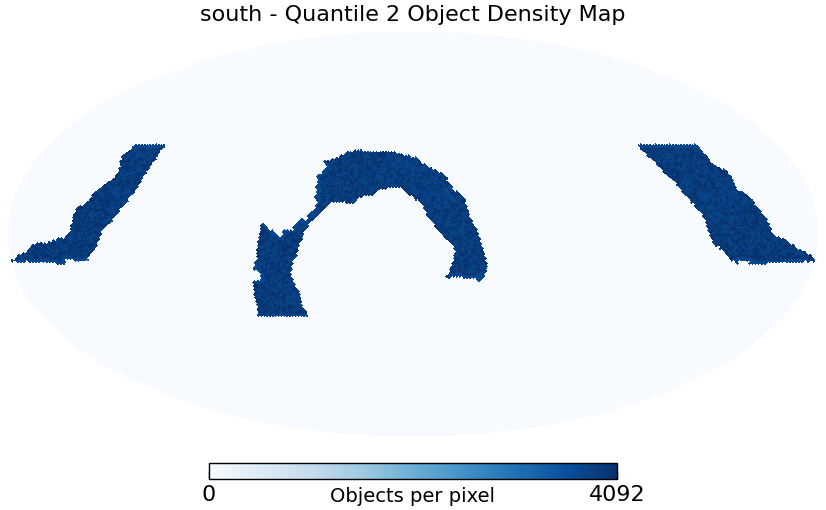

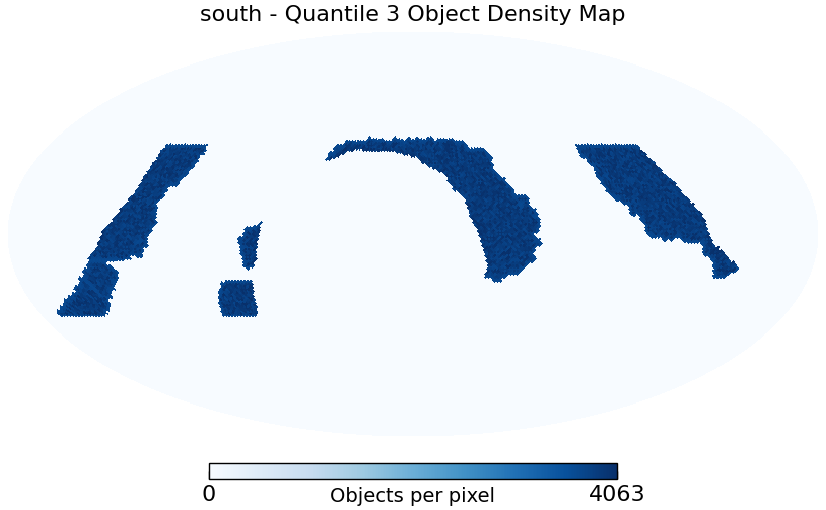

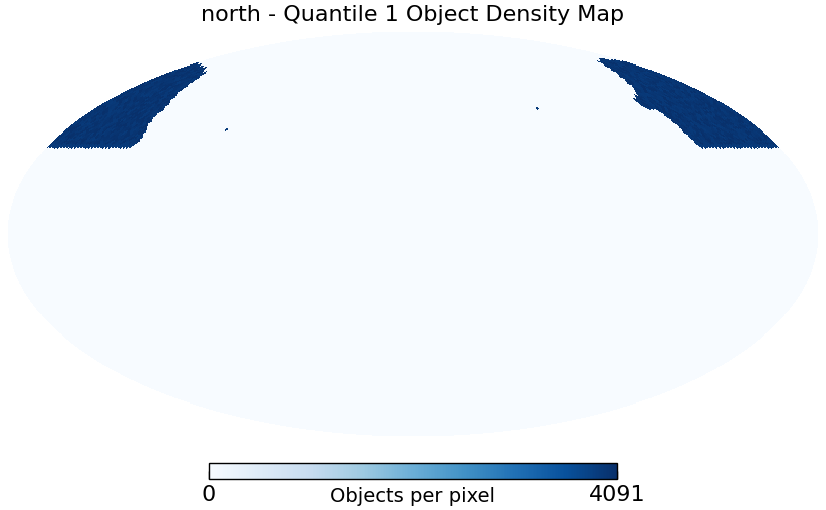

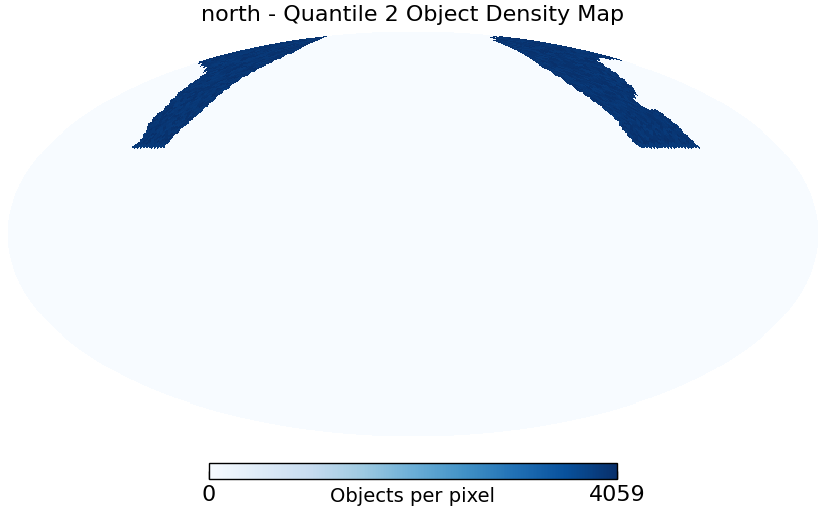

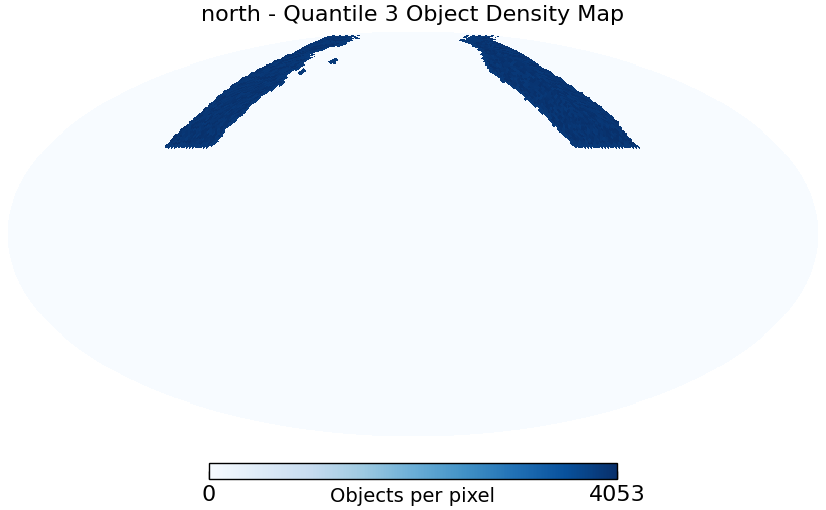

In [53]:
markers = {'north': 'o', 'south': '*'}
for part in ['south','north']: 
    sys_map = hp.read_map(f'{path}/{part}_Stellar_Density_AllWISE_nside_64.fits')
    random_pix  = hp.ang2pix(64, np.radians(90.0 - randoms_part[part]['DEC']), np.radians(randoms_part[part]['RA']), nest=False)
    bin_indices_randoms = np.digitize(sys_map[random_pix], bins=quantile_edges) -1
    bin_indices_randoms = np.clip(bin_indices_randoms, 0, nbins-1)
    bin_mask_randoms_64 = {}
    

    bin_indices = np.digitize(sys_map[gal_pix[part]], bins=quantile_edges) -1
    bin_indices = np.clip(bin_indices, 0, nbins-1)
    bin_mask_64 = {}
    for i in np.unique(bin_indices):
        bin_mask_64[i] = bin_indices == i
    for i in np.unique(bin_indices_randoms):
        bin_mask_randoms_64[i] = bin_indices_randoms == i

    mask = hp.read_map(f'{path}/{part}_mask_nside_64_for_systmatics_20M.fits')
    dat = cat[part][cat[part]['DEC']>=32.375] if part=='north' else cat[part][cat[part]['DEC']<32.375]
    #dat = dat[mask>0]
    quantile_sys = {}
    quantile_sys_randoms = {}

    
    colors= ['red','green','blue']
    for i in np.unique(bin_indices):
        quantile_sys_randoms[i] = randoms_part[part][bin_mask_randoms_64[i]]
        quantile_sys[i] = dat[bin_mask_64[i]]
        pix = points_to_map(quantile_sys_randoms[i]['RA'], quantile_sys_randoms[i]['DEC'], nside=64)
        hp.mollview(pix, title=f'{part} - Quantile {i+1} Object Density Map', unit='Objects per pixel', cmap='Blues',norm = 'hist')

    # for i in np.unique(bin_indices):
    #     quantile_sys_randoms[i] = randoms_part[part][bin_mask_randoms_64[i]]
    #     quantile_sys[i] = dat[bin_mask_64[i]]
    #     #plt.plot(quantile_sys[i]['RA'], quantile_sys[i]['DEC'], '.', label=f'Quantile {i+1}',alpha=0.6)
    #     pix = points_to_map(quantile_sys[i]['RA'], quantile_sys[i]['DEC'], nside=64)
    #     #hp.mollview(pix, title=f'Quantile {i+1} Object Density Map', unit='Objects per pixel', cmap='Blues',norm = 'hist')
    #     theta, w_theta = compute_w_theta(quantile_sys[i], quantile_sys_randoms[i],err_bars = False )
    #     plt.loglog(theta, w_theta[0], label=f'{part} - Quantile {i+1}',ls='None',marker=markers[part], color=colors[i])
    #     #plt.errorbar(theta, w_theta[0], yerr=sig, label=f'{part} - Quantile {i+1}',ls='None',marker=markers[part], color=colors[i])
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel(r'$\theta$ (degrees)')
# plt.ylabel(r'$w(\theta)$')
# plt.legend()

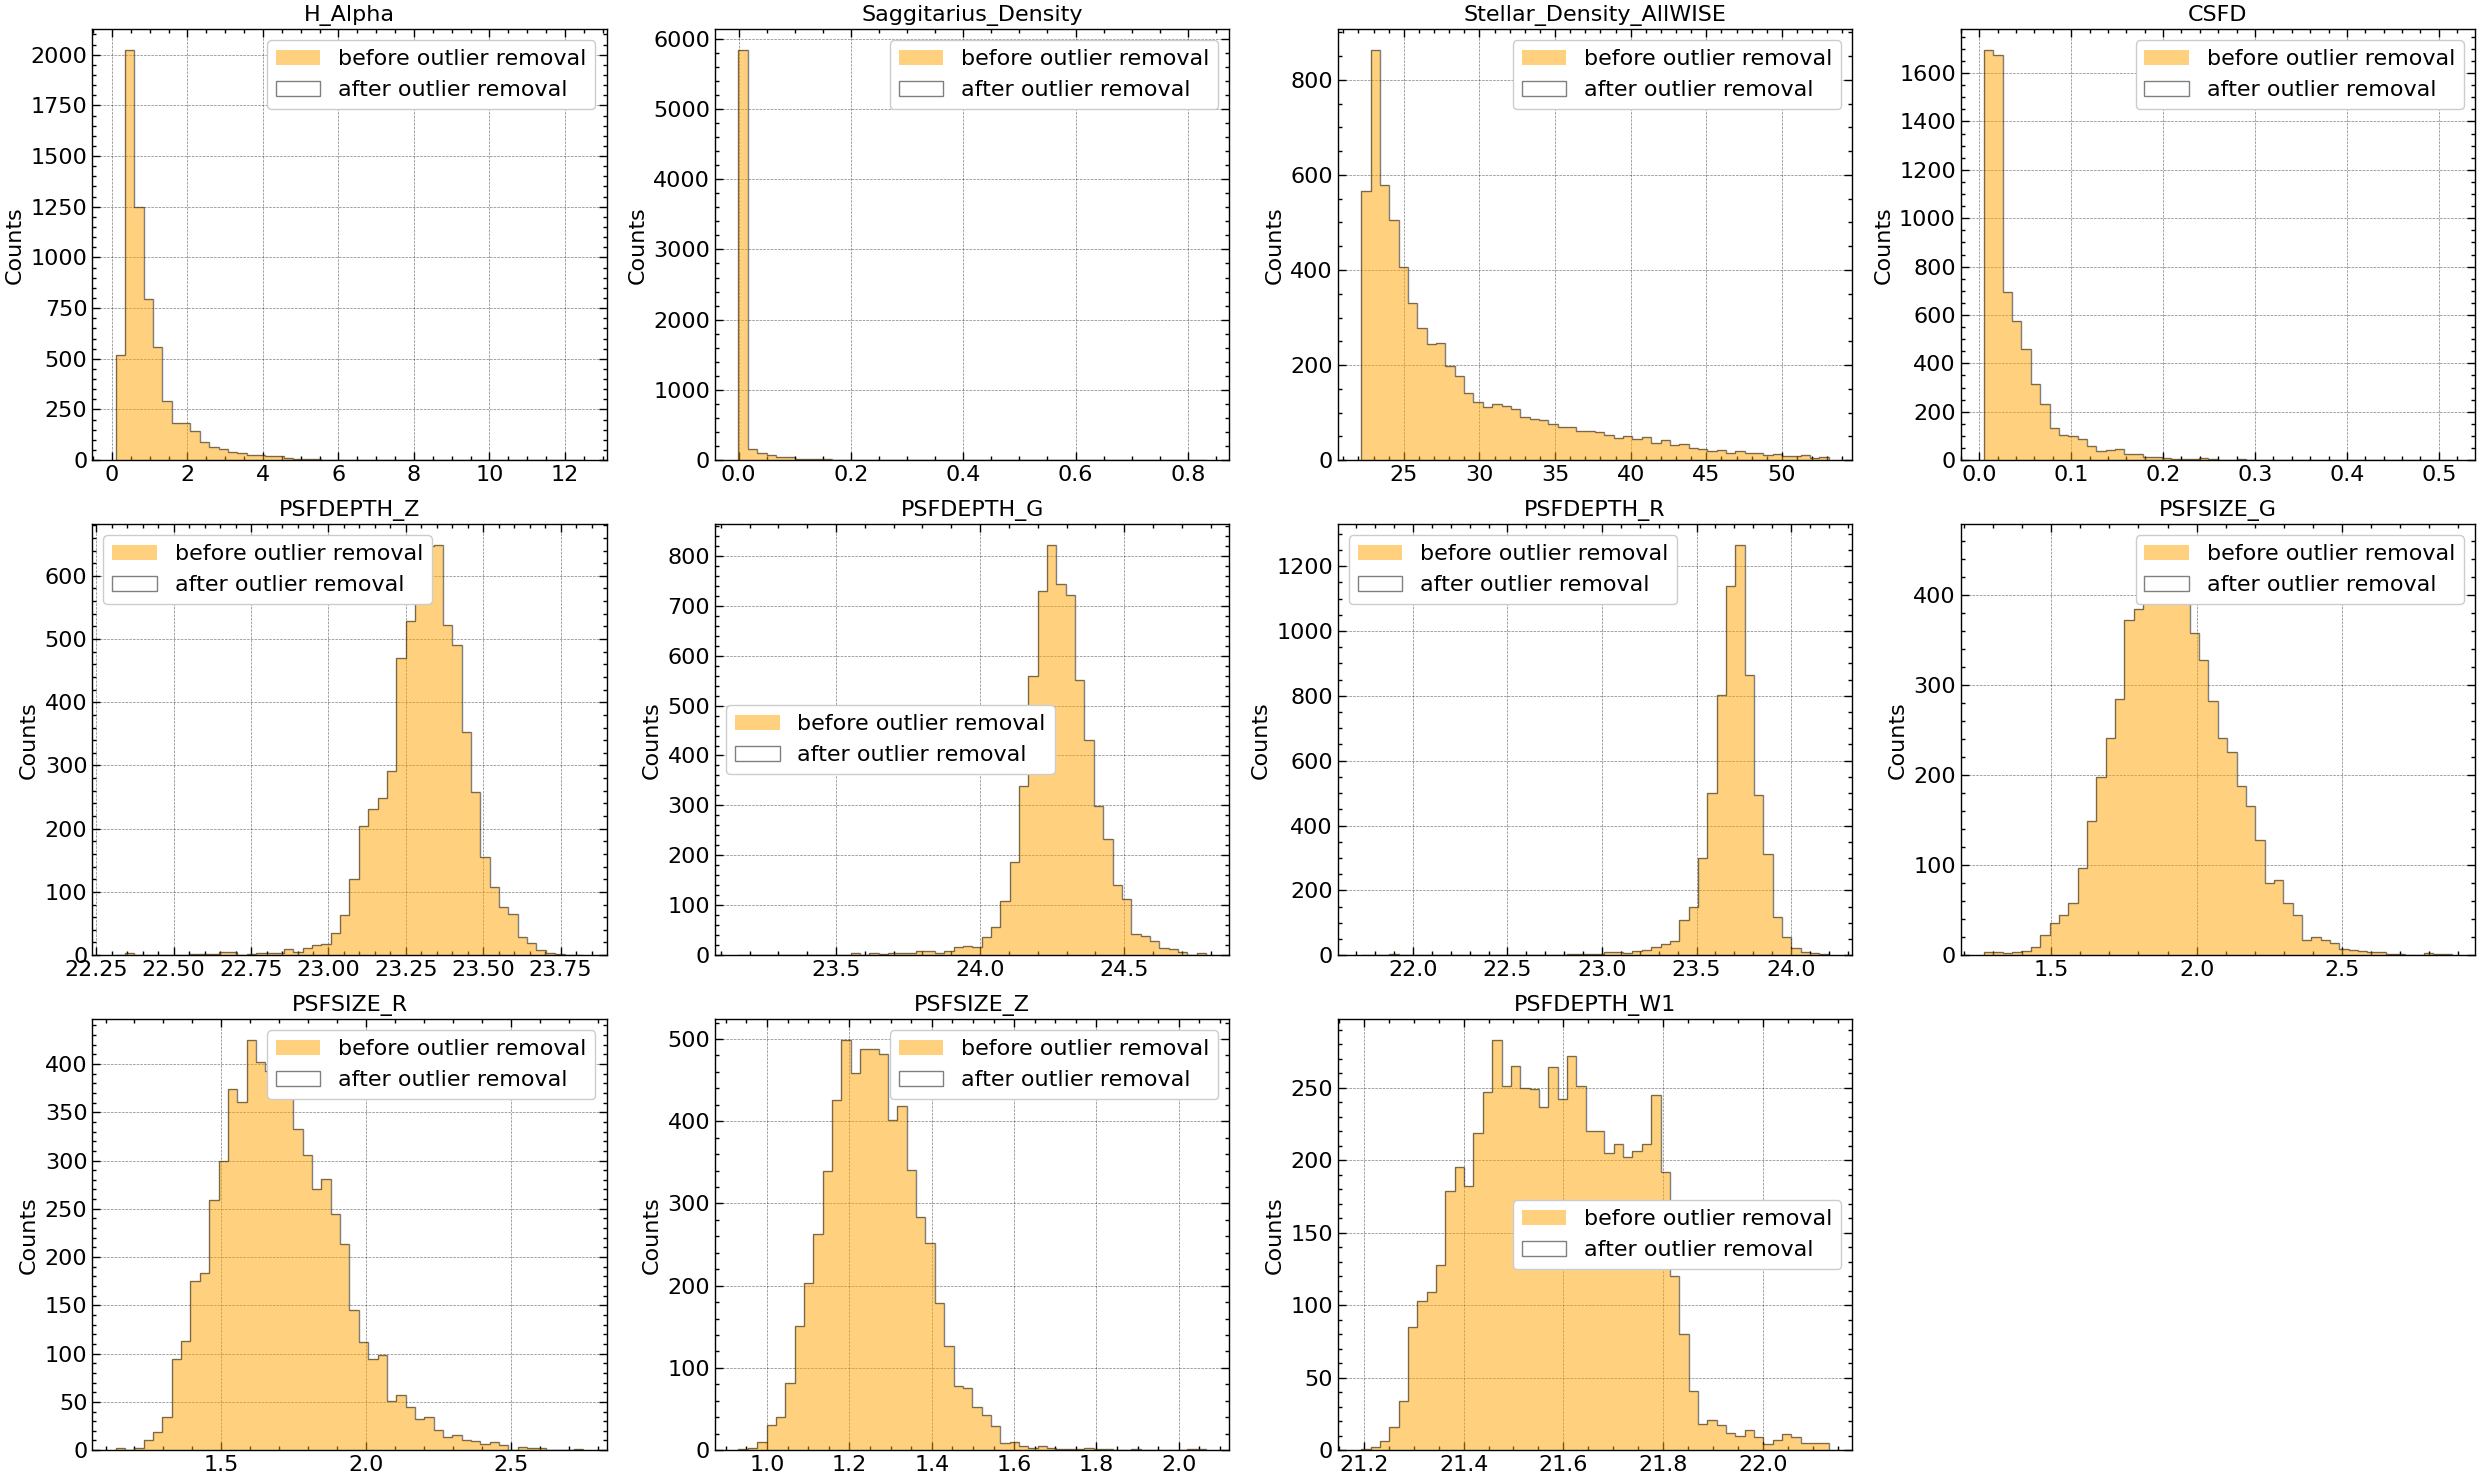

In [ ]:
#removing outliers systematics
#if remove_outliers:
if True:
    masks  = []
    limits = []
    
    # Calculate number of rows needed for subplots
    n_sys = len(systematics_list)
    n_cols = 4
    n_rows = (n_sys + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5*n_rows))
    axes = axes.flatten()
    
    for idx, sys_name in enumerate(systematics_list):
        sys_map = systematics_maps[sys_name]
        valid = (mask>0) & np.isfinite(sys_map)
        counts, bin_edges = np.histogram(sys_map[valid], bins=50)
        frac_area = counts/np.sum(counts)
        bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
        order = np.argsort(bin_centers)
        cumfrac = np.cumsum(frac_area[order])
        cum_mask = np.zeros_like(frac_area, dtype=bool)
        cum_mask[order] = (cumfrac >=0.025) & (cumfrac <=0.975)
        # if kind == 'equal':
        #     ul0 = (1-val/100/2)
        #     ll0 = (val/100/2)

        #     ul = np.min(bin_centers[(cumfrac >ul0)])
        #     try:
        #         ll = np.max(bin_centers[(cumfrac <ll0)])
        #     except:
        #         print('no lower limit')
        #         ll = np.min(sys_map[valid])
        # elif kind == 'partial_percentile':
        #     if sys_name == 'CSFD' or sys_name == 'Saggitarius_Density' or sys_name == 'Stellar_Density_AllWISE' or sys_name == 'H_Alpha':
        #         ul =  np.min(bin_centers[(cumfrac >0.95)])
        #     else:
        #         ul =  np.min(bin_centers[(cumfrac >=0.99)])
        #     try:
        #         ll = np.max(bin_centers[(cumfrac <0.01)])
        #     except:
        #         print('no lower limit')
        #         ll = np.min(sys_map[valid])

        
        #removal_mask = (sys_map >=ll) & (sys_map<=ul)
        usable_maps = sys_map#[removal_mask]
        
        #limits.append((ll, ul))
        #print('Number of elements removed for ', sys_name, ': ', np.sum(~removal_mask ))
        
        axes[idx].hist(usable_maps, bins=bin_edges, alpha=0.5, label=f'before outlier removal', color='orange')
        axes[idx].hist(sys_map[valid], bins=bin_edges, alpha=0.5, label=f'after outlier removal', color='k', histtype='step')
        axes[idx].legend()
        axes[idx].set_title(f'{sys_name}')
        axes[idx].set_ylabel('Counts')
        
        #masks.append(removal_mask)
    
    # Hide unused subplots
    for idx in range(n_sys, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    combined_masks = np.all(np.array(masks), axis=0)
else:
    combined_masks = mask>0
    kind = None
    val=None
#dir_name = f'multilinear_results/{part}'
#os.makedirs(dir_name, exist_ok=True)

In [44]:
tabe = fitsio.FITS('/user/animesh.sah/FP_CUTS/shape_combined_north_test/north_shape_combined_cuts.fits')[1].read()

In [ ]:
len(tabe)

ValueError: no field of name BBA